<a href="https://colab.research.google.com/github/DumuthuLakshan/explainable-ai-network-config-validation/blob/main/Data_Generation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import ipaddress
import pandas as pd
import numpy as np
from collections import defaultdict

random.seed(42)
np.random.seed(42)

NORMAL_PER_PROFILE = 600
DIRECT_ERROR_PER_TYPE = 240
CONTEXTUAL_ANOMALY_PER_TYPE = 250
CROSS_LINK_ANOMALY_PER_TYPE = 100

NETWORKS = [
    "HospitalNet", "SchoolNet", "CampusNet", "OfficeNet",
    "BranchNet", "DataCenterNet", "LabNet", "AdminNet",
    "FinanceNet", "ResearchNet", "CloudNet", "BackupNet"
]

PROFILES = {
    "router_to_router": {
        "normal_prefixes": [30],
        "expected_ranges": ["10"],
        "normal_roles": [("Router", "Router")],
        "normal_ip_base": "10"
    },
    "branch_lan": {
        "normal_prefixes": [24, 25],
        "expected_ranges": ["192.168"],
        "normal_roles": [("Router", "PC"), ("Router", "Switch")],
        "normal_ip_base": "192.168"
    },
    "campus_network": {
        "normal_prefixes": [23, 24],
        "expected_ranges": ["172.16"],
        "normal_roles": [("Router", "Switch"), ("Router", "AccessPoint")],
        "normal_ip_base": "172.16"
    },
    "datacenter_segment": {
        "normal_prefixes": [28, 29],
        "expected_ranges": ["10"],
        "normal_roles": [("Firewall", "Server"), ("Switch", "Server")],
        "normal_ip_base": "10"
    }
}

DEVICE_POOLS = {
    "Router": ["R1", "R2", "R3", "R4", "R5"],
    "Switch": ["SW1", "SW2", "SW3", "SW4"],
    "PC": ["PC1", "PC2", "PC3", "PC4", "PC5"],
    "Server": ["SRV1", "SRV2", "SRV3", "SRV4"],
    "Firewall": ["FW1", "FW2"],
    "AccessPoint": ["AP1", "AP2", "AP3"]
}

DIRECT_ERRORS = [
    "duplicate_ip",
    "subnet_mask_mismatch",
    "network_mismatch",
    "status_mismatch",
    "invalid_host_ip"
]

CONTEXTUAL_ANOMALIES = [
    "profile_subnet_mismatch",
    "device_role_mismatch",
    "ip_range_profile_mismatch",
    "gateway_role_mismatch"
]

USED_SUBNETS_BY_NETWORK = defaultdict(list)


def prefix_to_mask(prefix):
    return str(ipaddress.IPv4Network(f"0.0.0.0/{prefix}").netmask)


def get_prefix(mask):
    return ipaddress.IPv4Network(f"0.0.0.0/{mask}").prefixlen


def get_network_address(ip, mask):
    return str(ipaddress.ip_network(f"{ip}/{mask}", strict=False).network_address)


def get_network_cidr(ip, mask):
    return str(ipaddress.ip_network(f"{ip}/{mask}", strict=False))


def is_valid_host_ip(ip, mask):
    network = ipaddress.ip_network(f"{ip}/{mask}", strict=False)
    ip_obj = ipaddress.ip_address(ip)

    if ip_obj == network.network_address:
        return False

    if ip_obj == network.broadcast_address:
        return False

    return True


def subnet_capacity(prefix):
    if prefix >= 31:
        return 0

    return (2 ** (32 - prefix)) - 2


def get_ip_range_type(ip):
    parts = ip.split(".")
    first = int(parts[0])
    second = int(parts[1])

    if first == 10:
        return "10_private"

    if first == 192 and second == 168:
        return "192_private"

    if first == 172 and 16 <= second <= 31:
        return "172_private"

    return "other"


def get_last_octet(ip):
    return int(ip.split(".")[-1])


def has_used_conflict(network_name, network):
    for used in USED_SUBNETS_BY_NETWORK[network_name]:
        if network.overlaps(used):
            return True

    return False


def register_subnet(network_name, network):
    USED_SUBNETS_BY_NETWORK[network_name].append(network)


def random_host_block(prefix):
    block_size = 2 ** (32 - prefix)

    if block_size >= 256:
        return 0

    return random.choice(list(range(0, 256, block_size)))


def make_candidate_network(base, prefix):
    a = random.randint(1, 250)
    b = random.randint(1, 250)
    block = random_host_block(prefix)

    if base == "10":
        if prefix <= 24:
            return ipaddress.ip_network(f"10.{a}.{b}.0/{prefix}", strict=False)

        return ipaddress.ip_network(f"10.{a}.{b}.{block}/{prefix}", strict=False)

    if base == "192.168":
        if prefix <= 24:
            return ipaddress.ip_network(f"192.168.{a}.0/{prefix}", strict=False)

        return ipaddress.ip_network(f"192.168.{a}.{block}/{prefix}", strict=False)

    if base == "172.16":
        second_octet = random.randint(16, 31)

        if prefix <= 24:
            return ipaddress.ip_network(f"172.{second_octet}.{a}.0/{prefix}", strict=False)

        return ipaddress.ip_network(f"172.{second_octet}.{a}.{block}/{prefix}", strict=False)

    raise ValueError("Unknown IP base")


def create_network_for_profile(
    network_name,
    profile_name,
    prefix,
    force_wrong_range=False,
    register=True,
    avoid_conflict=True
):
    profile = PROFILES[profile_name]

    if force_wrong_range:
        possible_bases = ["10", "192.168", "172.16"]
        expected = profile["expected_ranges"]

        possible_bases = [
            base for base in possible_bases
            if base not in expected
        ]

        if prefix <= 23 and "192.168" in possible_bases and len(possible_bases) > 1:
            possible_bases = [
                base for base in possible_bases
                if base != "192.168"
            ]

        base = random.choice(possible_bases)

    else:
        base = profile["normal_ip_base"]

    for _ in range(50000):
        network = make_candidate_network(base, prefix)

        if avoid_conflict and has_used_conflict(network_name, network):
            continue

        hosts = list(network.hosts())

        if len(hosts) < 2:
            continue

        ip_a = str(hosts[0])
        ip_b = str(hosts[1])

        if register:
            register_subnet(network_name, network)

        return network, ip_a, ip_b

    raise RuntimeError(
        f"Could not create non-overlapping subnet for {network_name} {profile_name}/{prefix}"
    )


def choose_device_pair(network_name, role_a, role_b):
    if role_a == role_b:
        choices = random.sample(DEVICE_POOLS[role_a], 2)

        device_a = f"{network_name}_{choices[0]}"
        device_b = f"{network_name}_{choices[1]}"

    else:
        device_a = f"{network_name}_{random.choice(DEVICE_POOLS[role_a])}"
        device_b = f"{network_name}_{random.choice(DEVICE_POOLS[role_b])}"

    return device_a, device_b


def build_row(
    sample_id,
    network_name,
    profile_name,
    ip_a,
    ip_b,
    prefix_a,
    prefix_b,
    role_a,
    role_b,
    label,
    risk_level,
    error_type
):
    device_a, device_b = choose_device_pair(network_name, role_a, role_b)

    return {
        "Sample_ID": sample_id,
        "Network": network_name,
        "Link_ID": f"L{sample_id}",
        "Link_Profile": profile_name,
        "Device_A": device_a,
        "Device_B": device_b,
        "Device_A_Role": role_a,
        "Device_B_Role": role_b,
        "Interface_A": "Gi0/1",
        "Interface_B": "Gi0/1",
        "IP_A": ip_a,
        "IP_B": ip_b,
        "Subnet_A": prefix_to_mask(prefix_a),
        "Subnet_B": prefix_to_mask(prefix_b),
        "Prefix_A": prefix_a,
        "Prefix_B": prefix_b,
        "Status_A": "up",
        "Status_B": "up",
        "Label": label,
        "Risk_Level": risk_level,
        "Error_Type": error_type
    }


def create_normal_sample(sample_id, profile_name):
    network_name = random.choice(NETWORKS)

    profile = PROFILES[profile_name]

    prefix = random.choice(profile["normal_prefixes"])

    network, ip_a, ip_b = create_network_for_profile(
        network_name,
        profile_name,
        prefix
    )

    role_a, role_b = random.choice(profile["normal_roles"])

    return build_row(
        sample_id,
        network_name,
        profile_name,
        ip_a,
        ip_b,
        prefix,
        prefix,
        role_a,
        role_b,
        label=0,
        risk_level="Low",
        error_type="none"
    )

def create_direct_error_sample(sample_id, error_type):
    profile_name = random.choice(list(PROFILES.keys()))

    row = create_normal_sample(sample_id, profile_name)

    row["Label"] = 1
    row["Risk_Level"] = "High"
    row["Error_Type"] = error_type

    if error_type == "duplicate_ip":
        row["IP_B"] = row["IP_A"]

    elif error_type == "subnet_mask_mismatch":
        possible_prefixes = [23, 24, 25, 28, 29, 30]

        wrong_prefix = random.choice([
            prefix for prefix in possible_prefixes
            if prefix != row["Prefix_A"]
        ])

        row["Prefix_B"] = wrong_prefix
        row["Subnet_B"] = prefix_to_mask(wrong_prefix)
        row["Risk_Level"] = "Medium"

    elif error_type == "network_mismatch":
        wrong_network, wrong_ip_a, wrong_ip_b = create_network_for_profile(
            row["Network"],
            row["Link_Profile"],
            row["Prefix_B"],
            force_wrong_range=True,
            register=False,
            avoid_conflict=True
        )

        row["IP_B"] = wrong_ip_b

    elif error_type == "status_mismatch":
        row["Status_B"] = "down"
        row["Risk_Level"] = "Medium"

    elif error_type == "invalid_host_ip":
        network = ipaddress.ip_network(
            get_network_cidr(row["IP_A"], row["Subnet_A"]),
            strict=False
        )

        row["IP_A"] = str(network.network_address)

    return row


def create_contextual_anomaly_sample(sample_id, anomaly_type):
    network_name = random.choice(NETWORKS)

    if anomaly_type == "profile_subnet_mismatch":
        profile_name = random.choice(list(PROFILES.keys()))

        if profile_name == "router_to_router":
            wrong_prefix = 24

        elif profile_name == "branch_lan":
            wrong_prefix = 30

        elif profile_name == "campus_network":
            wrong_prefix = 30

        else:
            wrong_prefix = 24

        network, ip_a, ip_b = create_network_for_profile(
            network_name,
            profile_name,
            wrong_prefix
        )

        role_a, role_b = random.choice(PROFILES[profile_name]["normal_roles"])

        return build_row(
            sample_id,
            network_name,
            profile_name,
            ip_a,
            ip_b,
            wrong_prefix,
            wrong_prefix,
            role_a,
            role_b,
            label=1,
            risk_level="Medium",
            error_type=anomaly_type
        )

    elif anomaly_type == "device_role_mismatch":
        profile_name = random.choice(list(PROFILES.keys()))

        prefix = random.choice(PROFILES[profile_name]["normal_prefixes"])

        network, ip_a, ip_b = create_network_for_profile(
            network_name,
            profile_name,
            prefix
        )

        wrong_roles = {
            "router_to_router": ("PC", "PC"),
            "branch_lan": ("Server", "Firewall"),
            "campus_network": ("PC", "Server"),
            "datacenter_segment": ("PC", "AccessPoint")
        }

        role_a, role_b = wrong_roles[profile_name]

        return build_row(
            sample_id,
            network_name,
            profile_name,
            ip_a,
            ip_b,
            prefix,
            prefix,
            role_a,
            role_b,
            label=1,
            risk_level="Medium",
            error_type=anomaly_type
        )

    elif anomaly_type == "ip_range_profile_mismatch":
        profile_name = random.choice(list(PROFILES.keys()))

        prefix = random.choice(PROFILES[profile_name]["normal_prefixes"])

        network, ip_a, ip_b = create_network_for_profile(
            network_name,
            profile_name,
            prefix,
            force_wrong_range=True
        )

        role_a, role_b = random.choice(PROFILES[profile_name]["normal_roles"])

        return build_row(
            sample_id,
            network_name,
            profile_name,
            ip_a,
            ip_b,
            prefix,
            prefix,
            role_a,
            role_b,
            label=1,
            risk_level="Medium",
            error_type=anomaly_type
        )

    elif anomaly_type == "gateway_role_mismatch":
        profile_name = random.choice(["branch_lan", "campus_network"])

        prefix = 24

        network, ip_a, ip_b = create_network_for_profile(
            network_name,
            profile_name,
            prefix
        )

        return build_row(
            sample_id,
            network_name,
            profile_name,
            ip_a,
            ip_b,
            prefix,
            prefix,
            "PC",
            "Router",
            label=1,
            risk_level="Medium",
            error_type=anomaly_type
        )

    raise ValueError("Unknown contextual anomaly type")


def create_duplicate_subnet_pair(sample_id):
    network_name = random.choice(NETWORKS)

    profile_name = "datacenter_segment"
    prefix = 29

    network, ip_a, ip_b = create_network_for_profile(
        network_name,
        profile_name,
        prefix
    )

    hosts = list(network.hosts())

    row1 = build_row(
        sample_id,
        network_name,
        profile_name,
        str(hosts[0]),
        str(hosts[1]),
        prefix,
        prefix,
        "Switch",
        "Server",
        label=1,
        risk_level="High",
        error_type="duplicate_subnet"
    )

    row2 = build_row(
        sample_id + 1,
        network_name,
        profile_name,
        str(hosts[2]),
        str(hosts[3]),
        prefix,
        prefix,
        "Firewall",
        "Server",
        label=1,
        risk_level="High",
        error_type="duplicate_subnet"
    )

    return row1, row2


def create_overlapping_subnet_pair(sample_id):
    network_name = random.choice(NETWORKS)

    for _ in range(50000):
        a = random.randint(1, 250)
        b = random.randint(1, 250)

        parent_network = ipaddress.ip_network(
            f"10.{a}.{b}.0/28",
            strict=False
        )

        child_network = ipaddress.ip_network(
            f"10.{a}.{b}.0/30",
            strict=False
        )

        if has_used_conflict(network_name, parent_network) or has_used_conflict(network_name, child_network):
            continue

        register_subnet(network_name, parent_network)
        register_subnet(network_name, child_network)

        parent_hosts = list(parent_network.hosts())
        child_hosts = list(child_network.hosts())

        row1 = build_row(
            sample_id,
            network_name,
            "datacenter_segment",
            str(parent_hosts[4]),
            str(parent_hosts[5]),
            28,
            28,
            "Switch",
            "Server",
            label=1,
            risk_level="High",
            error_type="overlapping_subnet"
        )

        row2 = build_row(
            sample_id + 1,
            network_name,
            "router_to_router",
            str(child_hosts[0]),
            str(child_hosts[1]),
            30,
            30,
            "Router",
            "Router",
            label=1,
            risk_level="High",
            error_type="overlapping_subnet"
        )

        return row1, row2

    raise RuntimeError("Could not create overlapping subnet pair")


def add_graph_based_features(raw_df):
    raw_df = raw_df.copy()

    device_degree = defaultdict(int)

    for _, row in raw_df.iterrows():
        device_degree[row["Device_A"]] += 1
        device_degree[row["Device_B"]] += 1

    raw_df["device_a_degree"] = raw_df["Device_A"].map(device_degree)
    raw_df["device_b_degree"] = raw_df["Device_B"].map(device_degree)

    raw_df["Subnet_CIDR_A"] = raw_df.apply(
        lambda row: get_network_cidr(row["IP_A"], row["Subnet_A"]),
        axis=1
    )

    raw_df["subnet_reuse_count"] = raw_df.groupby(
        ["Network", "Subnet_CIDR_A"]
    )["Subnet_CIDR_A"].transform("count")

    raw_df["duplicate_subnet_flag"] = (
        raw_df["subnet_reuse_count"] > 1
    ).astype(int)

    raw_df["overlapping_subnet_flag"] = 0

    for network_name, group in raw_df.groupby("Network"):
        idx_list = group.index.tolist()

        subnet_objects = [
            ipaddress.ip_network(raw_df.loc[idx, "Subnet_CIDR_A"], strict=False)
            for idx in idx_list
        ]

        for local_i, subnet_i in enumerate(subnet_objects):
            overlap_found = 0

            for local_j, subnet_j in enumerate(subnet_objects):
                if local_i == local_j:
                    continue

                if subnet_i.overlaps(subnet_j) and subnet_i != subnet_j:
                    overlap_found = 1
                    break

            raw_df.loc[idx_list[local_i], "overlapping_subnet_flag"] = overlap_found

    valid_role_pairs = {
        "router_to_router": [("Router", "Router")],
        "branch_lan": [("Router", "PC"), ("Router", "Switch")],
        "campus_network": [("Router", "Switch"), ("Router", "AccessPoint")],
        "datacenter_segment": [("Firewall", "Server"), ("Switch", "Server")]
    }

    def check_role_pair_valid(row):
        profile = row["Link_Profile"]

        role_pair = (
            row["Device_A_Role"],
            row["Device_B_Role"]
        )

        reverse_role_pair = (
            row["Device_B_Role"],
            row["Device_A_Role"]
        )

        allowed_pairs = valid_role_pairs.get(profile, [])

        if role_pair in allowed_pairs or reverse_role_pair in allowed_pairs:
            return 1

        return 0

    raw_df["role_pair_valid"] = raw_df.apply(check_role_pair_valid, axis=1)

    return raw_df

def generate_features(raw_df):
    feature_rows = []

    raw_df = add_graph_based_features(raw_df)

    for _, row in raw_df.iterrows():
        ip_a = row["IP_A"]
        ip_b = row["IP_B"]

        subnet_a = row["Subnet_A"]
        subnet_b = row["Subnet_B"]

        prefix_a = get_prefix(subnet_a)
        prefix_b = get_prefix(subnet_b)

        duplicate_ip = int(ip_a == ip_b)

        same_subnet_mask = int(subnet_a == subnet_b)

        same_network = int(
            get_network_address(ip_a, subnet_a)
            ==
            get_network_address(ip_b, subnet_b)
        )

        prefix_difference = abs(prefix_a - prefix_b)

        both_interfaces_up = int(
            row["Status_A"] == "up"
            and
            row["Status_B"] == "up"
        )

        invalid_host_a = int(
            not is_valid_host_ip(ip_a, subnet_a)
        )

        invalid_host_b = int(
            not is_valid_host_ip(ip_b, subnet_b)
        )

        subnet_capacity_a = subnet_capacity(prefix_a)
        subnet_capacity_b = subnet_capacity(prefix_b)

        host_number_a = get_last_octet(ip_a)
        host_number_b = get_last_octet(ip_b)

        gateway_ip_on_non_router = int(
            row["Link_Profile"] in ["branch_lan", "campus_network"]
            and
            host_number_a == 1
            and
            row["Device_A_Role"] != "Router"
        )

        ip_range_a = get_ip_range_type(ip_a)
        ip_range_b = get_ip_range_type(ip_b)

        expected_ranges = PROFILES[row["Link_Profile"]]["expected_ranges"]

        expected_ip_range_match = int(
            (
                ip_range_a == "10_private"
                and
                "10" in expected_ranges
            )
            or
            (
                ip_range_a == "192_private"
                and
                "192.168" in expected_ranges
            )
            or
            (
                ip_range_a == "172_private"
                and
                "172.16" in expected_ranges
            )
        )

        feature_rows.append({
            "Sample_ID": row["Sample_ID"],
            "Network": row["Network"],
            "Link_ID": row["Link_ID"],
            "Link_Profile": row["Link_Profile"],
            "Device_A_Role": row["Device_A_Role"],
            "Device_B_Role": row["Device_B_Role"],

            "Prefix_A": prefix_a,
            "Prefix_B": prefix_b,
            "duplicate_ip": duplicate_ip,
            "same_subnet_mask": same_subnet_mask,
            "same_network": same_network,
            "prefix_difference": prefix_difference,
            "both_interfaces_up": both_interfaces_up,
            "invalid_host_a": invalid_host_a,
            "invalid_host_b": invalid_host_b,
            "subnet_capacity_a": subnet_capacity_a,
            "subnet_capacity_b": subnet_capacity_b,
            "host_number_a": host_number_a,
            "host_number_b": host_number_b,
            "gateway_ip_on_non_router": gateway_ip_on_non_router,
            "expected_ip_range_match": expected_ip_range_match,

            # Graph-based features
            "device_a_degree": row["device_a_degree"],
            "device_b_degree": row["device_b_degree"],
            "subnet_reuse_count": row["subnet_reuse_count"],
            "duplicate_subnet_flag": row["duplicate_subnet_flag"],
            "overlapping_subnet_flag": row["overlapping_subnet_flag"],
            "role_pair_valid": row["role_pair_valid"],

            # Categorical features
            "IP_Range_A": ip_range_a,
            "IP_Range_B": ip_range_b,

            # Labels
            "Label": row["Label"],
            "Risk_Level": row["Risk_Level"],
            "Error_Type": row["Error_Type"]
        })

    return pd.DataFrame(feature_rows)


rows = []
sample_id = 1

# Normal data
for profile_name in PROFILES.keys():
    for _ in range(NORMAL_PER_PROFILE):
        rows.append(
            create_normal_sample(sample_id, profile_name)
        )

        sample_id += 1

# Direct errors
for error_type in DIRECT_ERRORS:
    for _ in range(DIRECT_ERROR_PER_TYPE):
        rows.append(
            create_direct_error_sample(sample_id, error_type)
        )

        sample_id += 1

# Contextual anomalies
for anomaly_type in CONTEXTUAL_ANOMALIES:
    for _ in range(CONTEXTUAL_ANOMALY_PER_TYPE):
        rows.append(
            create_contextual_anomaly_sample(sample_id, anomaly_type)
        )

        sample_id += 1

# Duplicate subnet anomalies
for _ in range(CROSS_LINK_ANOMALY_PER_TYPE):
    row1, row2 = create_duplicate_subnet_pair(sample_id)

    rows.append(row1)
    rows.append(row2)

    sample_id += 2

# Overlapping subnet anomalies
for _ in range(CROSS_LINK_ANOMALY_PER_TYPE):
    row1, row2 = create_overlapping_subnet_pair(sample_id)

    rows.append(row1)
    rows.append(row2)

    sample_id += 2

# Create raw dataframe
raw_df = pd.DataFrame(rows)

raw_df = raw_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Create feature dataframe
features_df = generate_features(raw_df)



raw_df.to_csv("dataset_v5_raw.csv", index=False)

features_df.to_csv("dataset_v5_features.csv", index=False)

with pd.ExcelWriter("dataset_v5_final.xlsx", engine="openpyxl") as writer:
    raw_df.to_excel(
        writer,
        sheet_name="Raw_Dataset",
        index=False
    )

    features_df.to_excel(
        writer,
        sheet_name="Feature_Dataset",
        index=False
    )


print("Dataset created successfully.")

print("\nRaw dataset shape:")
print(raw_df.shape)

print("\nFeature dataset shape:")
print(features_df.shape)

print("\nLabel distribution:")
print(raw_df["Label"].value_counts())

print("\nRisk level distribution:")
print(raw_df["Risk_Level"].value_counts())

print("\nError type distribution:")
print(raw_df["Error_Type"].value_counts())

print("\nLink profile distribution:")
print(raw_df["Link_Profile"].value_counts())

print("\nMissing values in raw dataset:")
print(raw_df.isnull().sum().sum())

print("\nMissing values in feature dataset:")
print(features_df.isnull().sum().sum())

print("\nGraph-based feature check by error type:")
print(
    features_df.groupby("Error_Type")[
        [
            "duplicate_subnet_flag",
            "overlapping_subnet_flag",
            "role_pair_valid",
            "expected_ip_range_match",
            "gateway_ip_on_non_router"
        ]
    ].mean()
)

print("\nFiles saved:")
print("dataset_v5_raw.csv")
print("dataset_v5_features.csv")
print("dataset_v5_final.xlsx")

Dataset created successfully.

Raw dataset shape:
(5000, 21)

Feature dataset shape:
(5000, 32)

Label distribution:
Label
1    2600
0    2400
Name: count, dtype: int64

Risk level distribution:
Risk_Level
Low       2400
Medium    1480
High      1120
Name: count, dtype: int64

Error type distribution:
Error_Type
none                         2400
profile_subnet_mismatch       250
gateway_role_mismatch         250
device_role_mismatch          250
ip_range_profile_mismatch     250
network_mismatch              240
duplicate_ip                  240
subnet_mask_mismatch          240
invalid_host_ip               240
status_mismatch               240
duplicate_subnet              200
overlapping_subnet            200
Name: count, dtype: int64

Link profile distribution:
Link_Profile
datacenter_segment    1414
branch_lan            1220
campus_network        1188
router_to_router      1178
Name: count, dtype: int64

Missing values in raw dataset:
0

Missing values in feature dataset:
0

Grap

# **Rule-Based Validation**

In [ ]:
import pandas as pd
import ipaddress


df = pd.read_csv("dataset_v5_raw.csv")


def get_network_address(ip, mask):
    return str(ipaddress.ip_network(f"{ip}/{mask}", strict=False).network_address)


def is_valid_host_ip(ip, mask):
    network = ipaddress.ip_network(f"{ip}/{mask}", strict=False)
    ip_obj = ipaddress.ip_address(ip)

    if ip_obj == network.network_address:
        return False

    if ip_obj == network.broadcast_address:
        return False

    return True


def basic_rule_based_validate(row):
    ip_a = row["IP_A"]
    ip_b = row["IP_B"]

    subnet_a = row["Subnet_A"]
    subnet_b = row["Subnet_B"]

    status_a = row["Status_A"]
    status_b = row["Status_B"]

    # Rule 1: Duplicate Ip address
    if ip_a == ip_b:
        return 1, "duplicate_ip", "High"

    # Rule 2: Invalid host IP address
    if not is_valid_host_ip(ip_a, subnet_a) or not is_valid_host_ip(ip_b, subnet_b):
        return 1, "invalid_host_ip", "High"

    # Rule 3: Subnet mask mismatch
    if subnet_a != subnet_b:
        return 1, "subnet_mask_mismatch", "Medium"

    # Rule 4: Network mismatch
    if get_network_address(ip_a, subnet_a) != get_network_address(ip_b, subnet_b):
        return 1, "network_mismatch", "High"

    # Rule 5: Interface status mismatch
    if status_a != status_b:
        return 1, "status_mismatch", "Medium"

    # If none of the five direct rules are violated
    return 0, "none", "Low"


results = df.apply(basic_rule_based_validate, axis=1)

df["Basic_Rule_Label"] = [result[0] for result in results]
df["Basic_Rule_Error_Type"] = [result[1] for result in results]
df["Basic_Rule_Risk_Level"] = [result[2] for result in results]


label_accuracy = (df["Label"] == df["Basic_Rule_Label"]).mean()

print("Basic Rule-Based Validation Completed")
print("Total Records:", len(df))

print("\nOverall Label Accuracy:")
print(label_accuracy)

print("\nActual Label Distribution:")
print(df["Label"].value_counts())

print("\nBasic Rule-Based Prediction Distribution:")
print(df["Basic_Rule_Label"].value_counts())

print("\nConfusion Matrix:")
print(
    pd.crosstab(
        df["Label"],
        df["Basic_Rule_Label"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)



direct_error_types = [
    "duplicate_ip",
    "subnet_mask_mismatch",
    "network_mismatch",
    "status_mismatch",
    "invalid_host_ip"
]

direct_error_df = df[df["Error_Type"].isin(direct_error_types)]

direct_error_accuracy = (
    direct_error_df["Error_Type"] == direct_error_df["Basic_Rule_Error_Type"]
).mean()

print("\nDirect Error Detection Accuracy:")
print(direct_error_accuracy)

print("\nDirect Error Actual Distribution:")
print(direct_error_df["Error_Type"].value_counts())

print("\nDirect Error Predicted Distribution:")
print(direct_error_df["Basic_Rule_Error_Type"].value_counts())



missed_anomalies = df[
    (df["Label"] == 1) &
    (df["Basic_Rule_Label"] == 0)
]

print("\nMissed Anomalies by Basic Rule-Based Model:")
print(missed_anomalies["Error_Type"].value_counts())

print("\nTotal Missed Anomalies:")
print(len(missed_anomalies))


df.to_csv("basic_rule_based_v5_results.csv", index=False)

with pd.ExcelWriter("basic_rule_based_v5_results.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Basic_Rule_Results", index=False)

print("\nFiles saved:")
print("basic_rule_based_v5_results.csv")
print("basic_rule_based_v5_results.xlsx")

Basic Rule-Based Validation Completed
Total Records: 5000

Overall Label Accuracy:
0.72

Actual Label Distribution:
Label
1    2600
0    2400
Name: count, dtype: int64

Basic Rule-Based Prediction Distribution:
Basic_Rule_Label
0    3800
1    1200
Name: count, dtype: int64

Confusion Matrix:
Predicted     0     1
Actual               
0          2400     0
1          1400  1200

Direct Error Detection Accuracy:
1.0

Direct Error Actual Distribution:
Error_Type
duplicate_ip            240
subnet_mask_mismatch    240
network_mismatch        240
invalid_host_ip         240
status_mismatch         240
Name: count, dtype: int64

Direct Error Predicted Distribution:
Basic_Rule_Error_Type
duplicate_ip            240
subnet_mask_mismatch    240
network_mismatch        240
invalid_host_ip         240
status_mismatch         240
Name: count, dtype: int64

Missed Anomalies by Basic Rule-Based Model:
Error_Type
device_role_mismatch         250
ip_range_profile_mismatch    250
gateway_role_mismatch

# **ML-Based Validation**

--- STEP 1: LOAD AND CLEAN DATASET ---

--- STEP 2: DATA SPLITTING ---

--- STEP 3: MODEL TRAINING ---

--- STEP 4: OPTIMIZING THRESHOLD ---

Optimal Threshold: 0.0709
              precision    recall  f1-score   support

  Normal (0)       0.00      0.00      0.00       367
 Anomaly (1)       0.87      1.00      0.93      2385

    accuracy                           0.87      2752
   macro avg       0.43      0.50      0.46      2752
weighted avg       0.75      0.87      0.80      2752



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


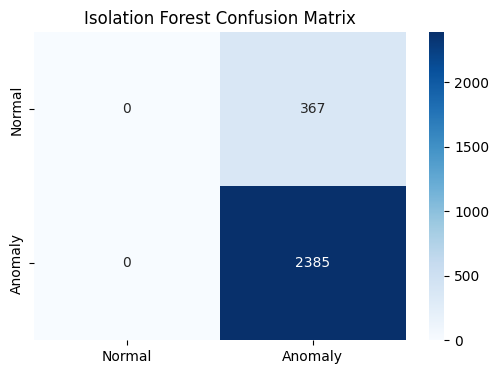

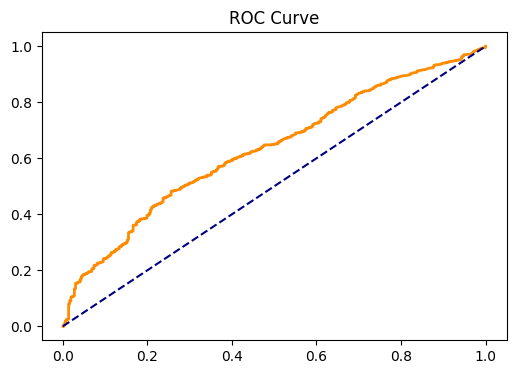

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network', 'Link_Profile',
                'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B',
                'Risk_Level', 'Error_Type']

features_to_check = df_features.drop(columns=cols_to_drop)
df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)

print("\n--- STEP 2: DATA SPLITTING ---")
core_features = [
    'Prefix_A', 'Prefix_B', 'duplicate_ip', 'same_subnet_mask',
    'prefix_difference', 'same_network', 'both_interfaces_up',
    'invalid_host_a', 'invalid_host_b', 'subnet_capacity_a',
    'subnet_capacity_b', 'device_a_degree', 'device_b_degree',
    'subnet_reuse_count'
]

df_normal = df_clean[df_clean['Label'] == 0]
df_anomaly = df_clean[df_clean['Label'] == 1]

# 80/20 Split for Normal Data
normal_train, normal_test = train_test_split(df_normal, test_size=0.20, random_state=42)

# Create Mixed Test Set
df_test_mixed = pd.concat([normal_test, df_anomaly])
X_train = normal_train[core_features]
X_test = df_test_mixed[core_features]
y_test_actual = df_test_mixed['Label']

print("\n--- STEP 3: MODEL TRAINING ---")
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_train)
test_scores = iso_forest.decision_function(X_test)

print("\n--- STEP 4: OPTIMIZING THRESHOLD ---")
thresholds = np.linspace(-0.2, 0.2, 500)
best_threshold = 0.0
best_f1 = 0.0

for t in thresholds:
    y_pred_temp = (test_scores < t).astype(int)
    current_f1 = f1_score(y_test_actual, y_pred_temp)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = t

y_pred_best = (test_scores < best_threshold).astype(int)

print(f"\nOptimal Threshold: {best_threshold:.4f}")
print(classification_report(y_test_actual, y_pred_best, target_names=["Normal (0)", "Anomaly (1)"]))

cm = confusion_matrix(y_test_actual, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Isolation Forest Confusion Matrix')
plt.show()

inverted_scores = -test_scores
fpr, tpr, _ = roc_curve(y_test_actual, inverted_scores)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("--- STEP 1: LOAD AND CLEAN PYTHON DATASET ---\n")
# Load the generated feature dataset
df_features = pd.read_csv('dataset_v5_features.csv')

# Drop identifiers to prevent data leakage during training
cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
features_to_check = df_features.drop(columns=cols_to_drop)

# Remove hidden mathematical duplicates to prevent the model from memorizing repeated errors
df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)
print(f"Dataset loaded and cleaned. Total unique records: {len(df_clean)}")


print("\n--- STEP 2: ONE-HOT ENCODING & FEATURE PREPARATION ---\n")
# Retain only the core mathematical features and categorical text (Drop rule-based "cheat" flags)
core_features = [
    'Prefix_A', 'Prefix_B', 'duplicate_ip', 'same_subnet_mask',
    'prefix_difference', 'same_network',
    'Device_A_Role', 'Device_B_Role', 'Link_Profile', 'Label'
]
df_core = df_clean[core_features]

# Apply One-Hot Encoding to translate categorical text (like 'Router' or 'PC') into binary columns
df_encoded = pd.get_dummies(df_core, columns=['Device_A_Role', 'Device_B_Role', 'Link_Profile'])

# Separate the dataset into features (X) and the target answers (y)
X = df_encoded.drop(columns=['Label'])
y = df_encoded['Label']

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {len(X_train)} records.")
print(f"Testing data size: {len(X_test)} records.")


print("\n--- STEP 3: TRAIN SUPERVISED RANDOM FOREST MODEL ---\n")
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the mixed dataset and the provided labels
rf_model.fit(X_train, y_train)
print("Random Forest model successfully trained.")


print("\n--- STEP 4: MODEL PERFORMANCE (CONFUSION MATRIX & METRICS) ---\n")
# Predict the labels for the unseen testing data
y_pred = rf_model.predict(X_test)

# Display the Confusion Matrix (True Positives, False Positives, etc.)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display the overall accuracy, precision, and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- STEP 1: LOAD AND CLEAN PYTHON DATASET ---

Dataset loaded and cleaned. Total unique records: 4324

--- STEP 2: ONE-HOT ENCODING & FEATURE PREPARATION ---

Training data size: 3459 records.
Testing data size: 865 records.

--- STEP 3: TRAIN SUPERVISED RANDOM FOREST MODEL ---

Random Forest model successfully trained.

--- STEP 4: MODEL PERFORMANCE (CONFUSION MATRIX & METRICS) ---

Confusion Matrix:
[[346  31]
 [198 290]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.92      0.75       377
           1       0.90      0.59      0.72       488

    accuracy                           0.74       865
   macro avg       0.77      0.76      0.73       865
weighted avg       0.79      0.74      0.73       865




--- STEP 5: ROC CURVE & EXACT AUC SCORE ---

Random Forest AUC Score: 0.8120



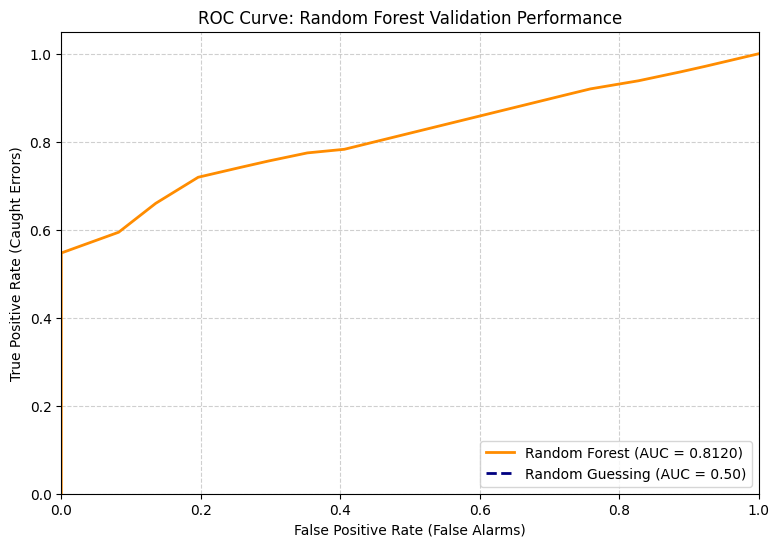

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("\n--- STEP 5: ROC CURVE & EXACT AUC SCORE ---\n")
# Get the probability scores for the Anomaly class (Label 1)
# Unlike the Isolation Forest's decision_function, Random Forest uses predict_proba
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rates, True Positive Rates, and the Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate the exact Area Under the Curve (AUC) score
roc_auc = auc(fpr, tpr)
print(f"Random Forest AUC Score: {roc_auc:.4f}\n")

# Generate the highly academic ROC Curve graph
plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([2], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

# Formatting the graph for your thesis
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Caught Errors)')
plt.title('ROC Curve: Random Forest Validation Performance')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

# Drop hidden mathematical duplicates to match your notebook
cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
features_to_check = df_features.drop(columns=cols_to_drop)
df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)

print("--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---")
# Include Error_Type ONLY for tracking, we will NOT train on it!
core_features = [
    'Prefix_A', 'Prefix_B', 'duplicate_ip', 'same_subnet_mask',
    'prefix_difference', 'same_network',
    'Device_A_Role', 'Device_B_Role', 'Link_Profile', 'Label', 'Error_Type'
]
df_core = df_clean[core_features]

# Apply One-Hot Encoding to translate categorical text
df_encoded = pd.get_dummies(df_core, columns=['Device_A_Role', 'Device_B_Role', 'Link_Profile'])

# Separate features (X), answer key (y), and the tracking column (Error_Type)
X = df_encoded.drop(columns=['Label', 'Error_Type'])
y = df_encoded['Label']
error_tracker = df_encoded['Error_Type']

print("--- STEP 3: TRAIN & TEST SPLIT ---")
# 80/20 split, maintaining the exact same random state
X_train, X_test, y_train, y_test, err_train, err_test = train_test_split(
    X, y, error_tracker, test_size=0.2, random_state=42
)

print("--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the unseen testing data
y_pred = rf_model.predict(X_test)

print("--- STEP 5: ANALYZE TRUE POSITIVES (CAUGHT ERRORS) ---")
# Create a results DataFrame merging the test labels, predictions, and error types
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error_Type': err_test
})

# Filter for errors that actually exist (Label == 1)
actual_errors = results_df[results_df['Actual'] == 1]

# Filter for errors the model successfully caught (Predicted == 1)
caught_errors = actual_errors[actual_errors['Predicted'] == 1]

# Count and display which errors were detected the most
caught_counts = caught_errors['Error_Type'].value_counts()
print("\n--- CAUGHT ERRORS BY TYPE ---")
print(caught_counts)

# Group by Direct vs Contextual based on your project definitions
direct_error_list = ['duplicate_ip', 'subnet_mask_mismatch', 'network_mismatch', 'status_mismatch', 'invalid_host_ip']
contextual_error_list = ['profile_subnet_mismatch', 'device_role_mismatch', 'ip_range_profile_mismatch', 'gateway_role_mismatch', 'duplicate_subnet', 'overlapping_subnet']

direct_caught = caught_counts[caught_counts.index.isin(direct_error_list)].sum()
contextual_caught = caught_counts[caught_counts.index.isin(contextual_error_list)].sum()

print("\n--- TOTAL BREAKDOWN ---")
print(f"Total Direct Errors Detected: {direct_caught}")
print(f"Total Contextual (Other) Errors Detected: {contextual_caught}")

--- STEP 1: LOAD AND CLEAN DATASET ---
--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---
--- STEP 3: TRAIN & TEST SPLIT ---
--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---
--- STEP 5: ANALYZE TRUE POSITIVES (CAUGHT ERRORS) ---

--- CAUGHT ERRORS BY TYPE ---
Error_Type
device_role_mismatch         49
duplicate_ip                 47
profile_subnet_mismatch      46
subnet_mask_mismatch         46
network_mismatch             44
gateway_role_mismatch        35
duplicate_subnet             15
status_mismatch               4
ip_range_profile_mismatch     2
invalid_host_ip               2
Name: count, dtype: int64

--- TOTAL BREAKDOWN ---
Total Direct Errors Detected: 143
Total Contextual (Other) Errors Detected: 147


# **Weighted-feature Experiment**

--- STEP 1: LOAD AND CLEAN DATASET ---
Original Records: 5000 | Cleaned Records: 4219

--- STEP 2: DATA SPLITTING (NOVELTY DETECTION) ---
Training strictly on 1467 NORMAL records...
Testing on mixed set of 2752 records (367 Normal, 2385 Anomalies)

--- STEP 3: APPLYING ARTIFICIAL FEATURE WEIGHTS ---
Weights applied successfully to force AI attention on explicit rules.

--- STEP 4: MODEL TRAINING ---

--- STEP 5: OPTIMIZING THRESHOLD ---
Optimal Threshold Found: -0.0445
Calibrated Standard Accuracy: 51.74%
Calibrated Balanced Accuracy: 61.09%

--- STEP 6: EVALUATION METRICS ---
True Positives (Caught Errors)     : 1153
True Negatives (Correctly Passed)  : 271
False Positives (FALSE ALARMS)     : 96
False Negatives (MISSED ERRORS)    : 1232

              precision    recall  f1-score   support

  Normal (0)       0.18      0.74      0.29       367
 Anomaly (1)       0.92      0.48      0.63      2385

    accuracy                           0.52      2752
   macro avg       0.55      0.6

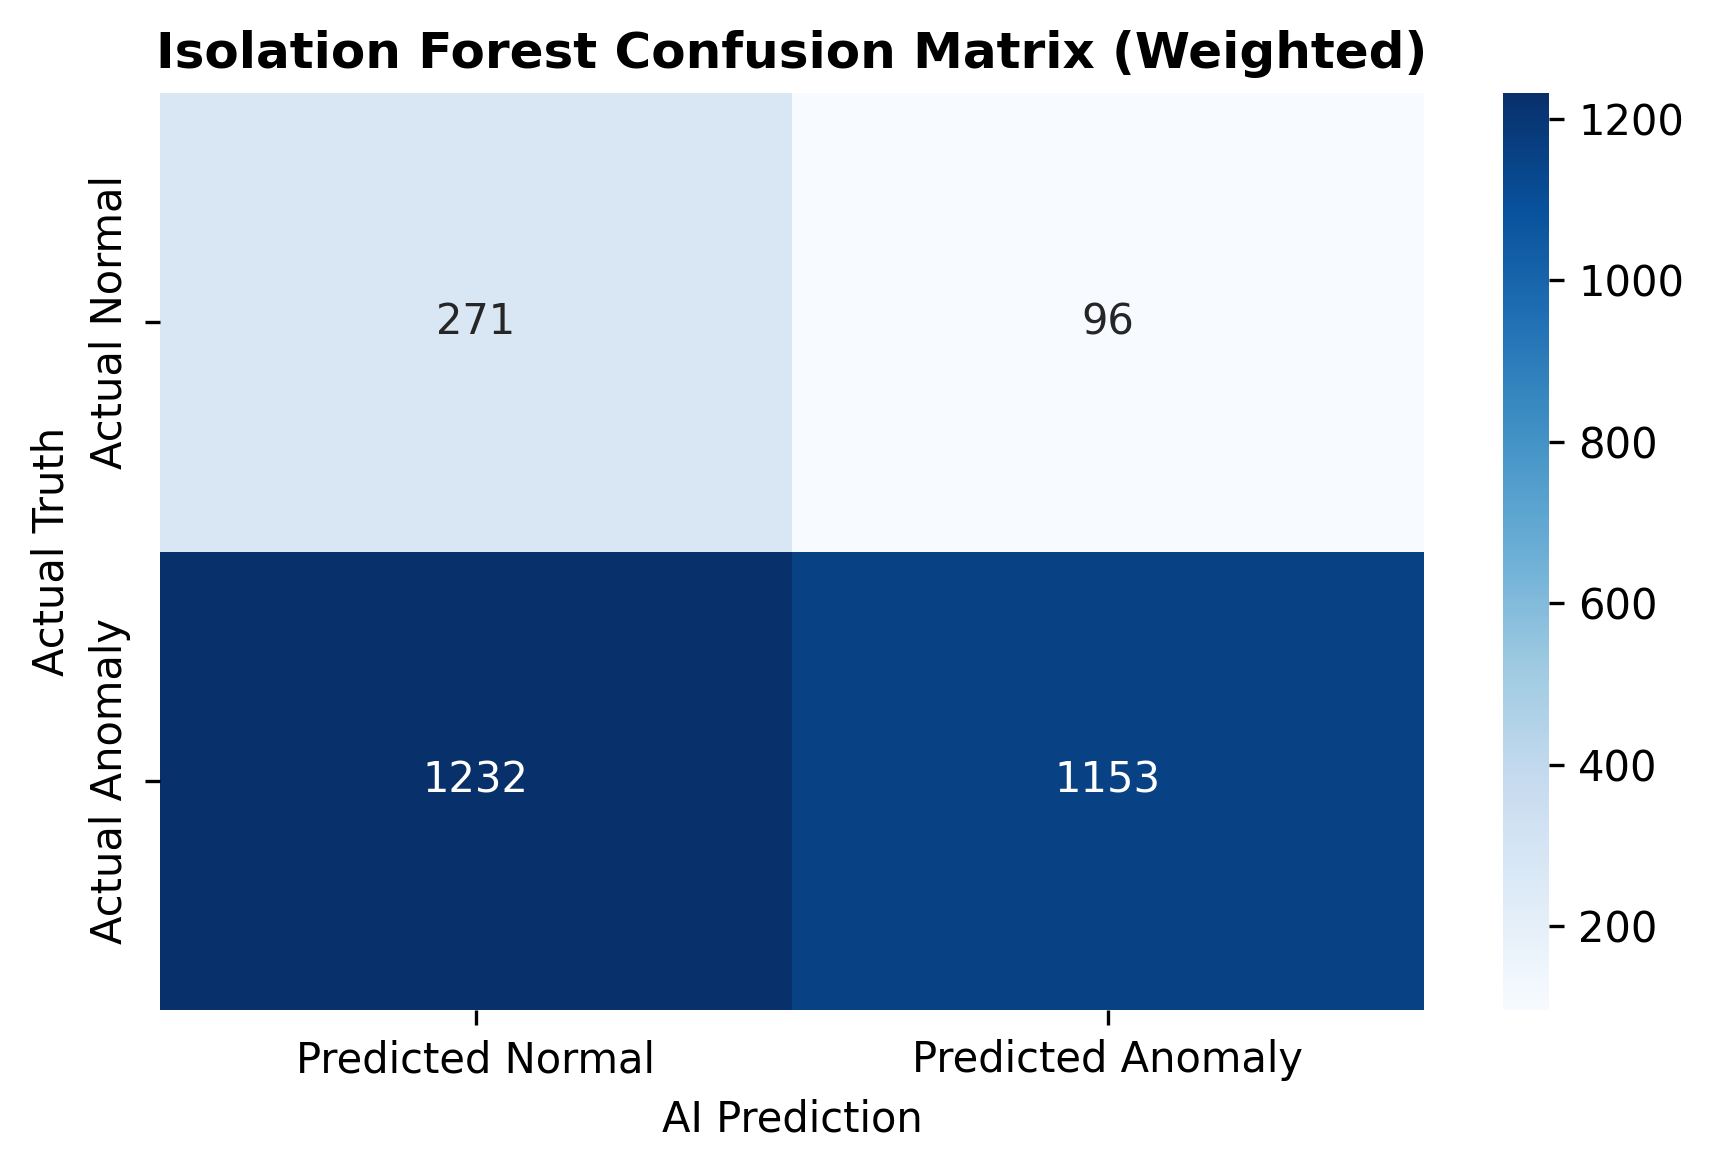

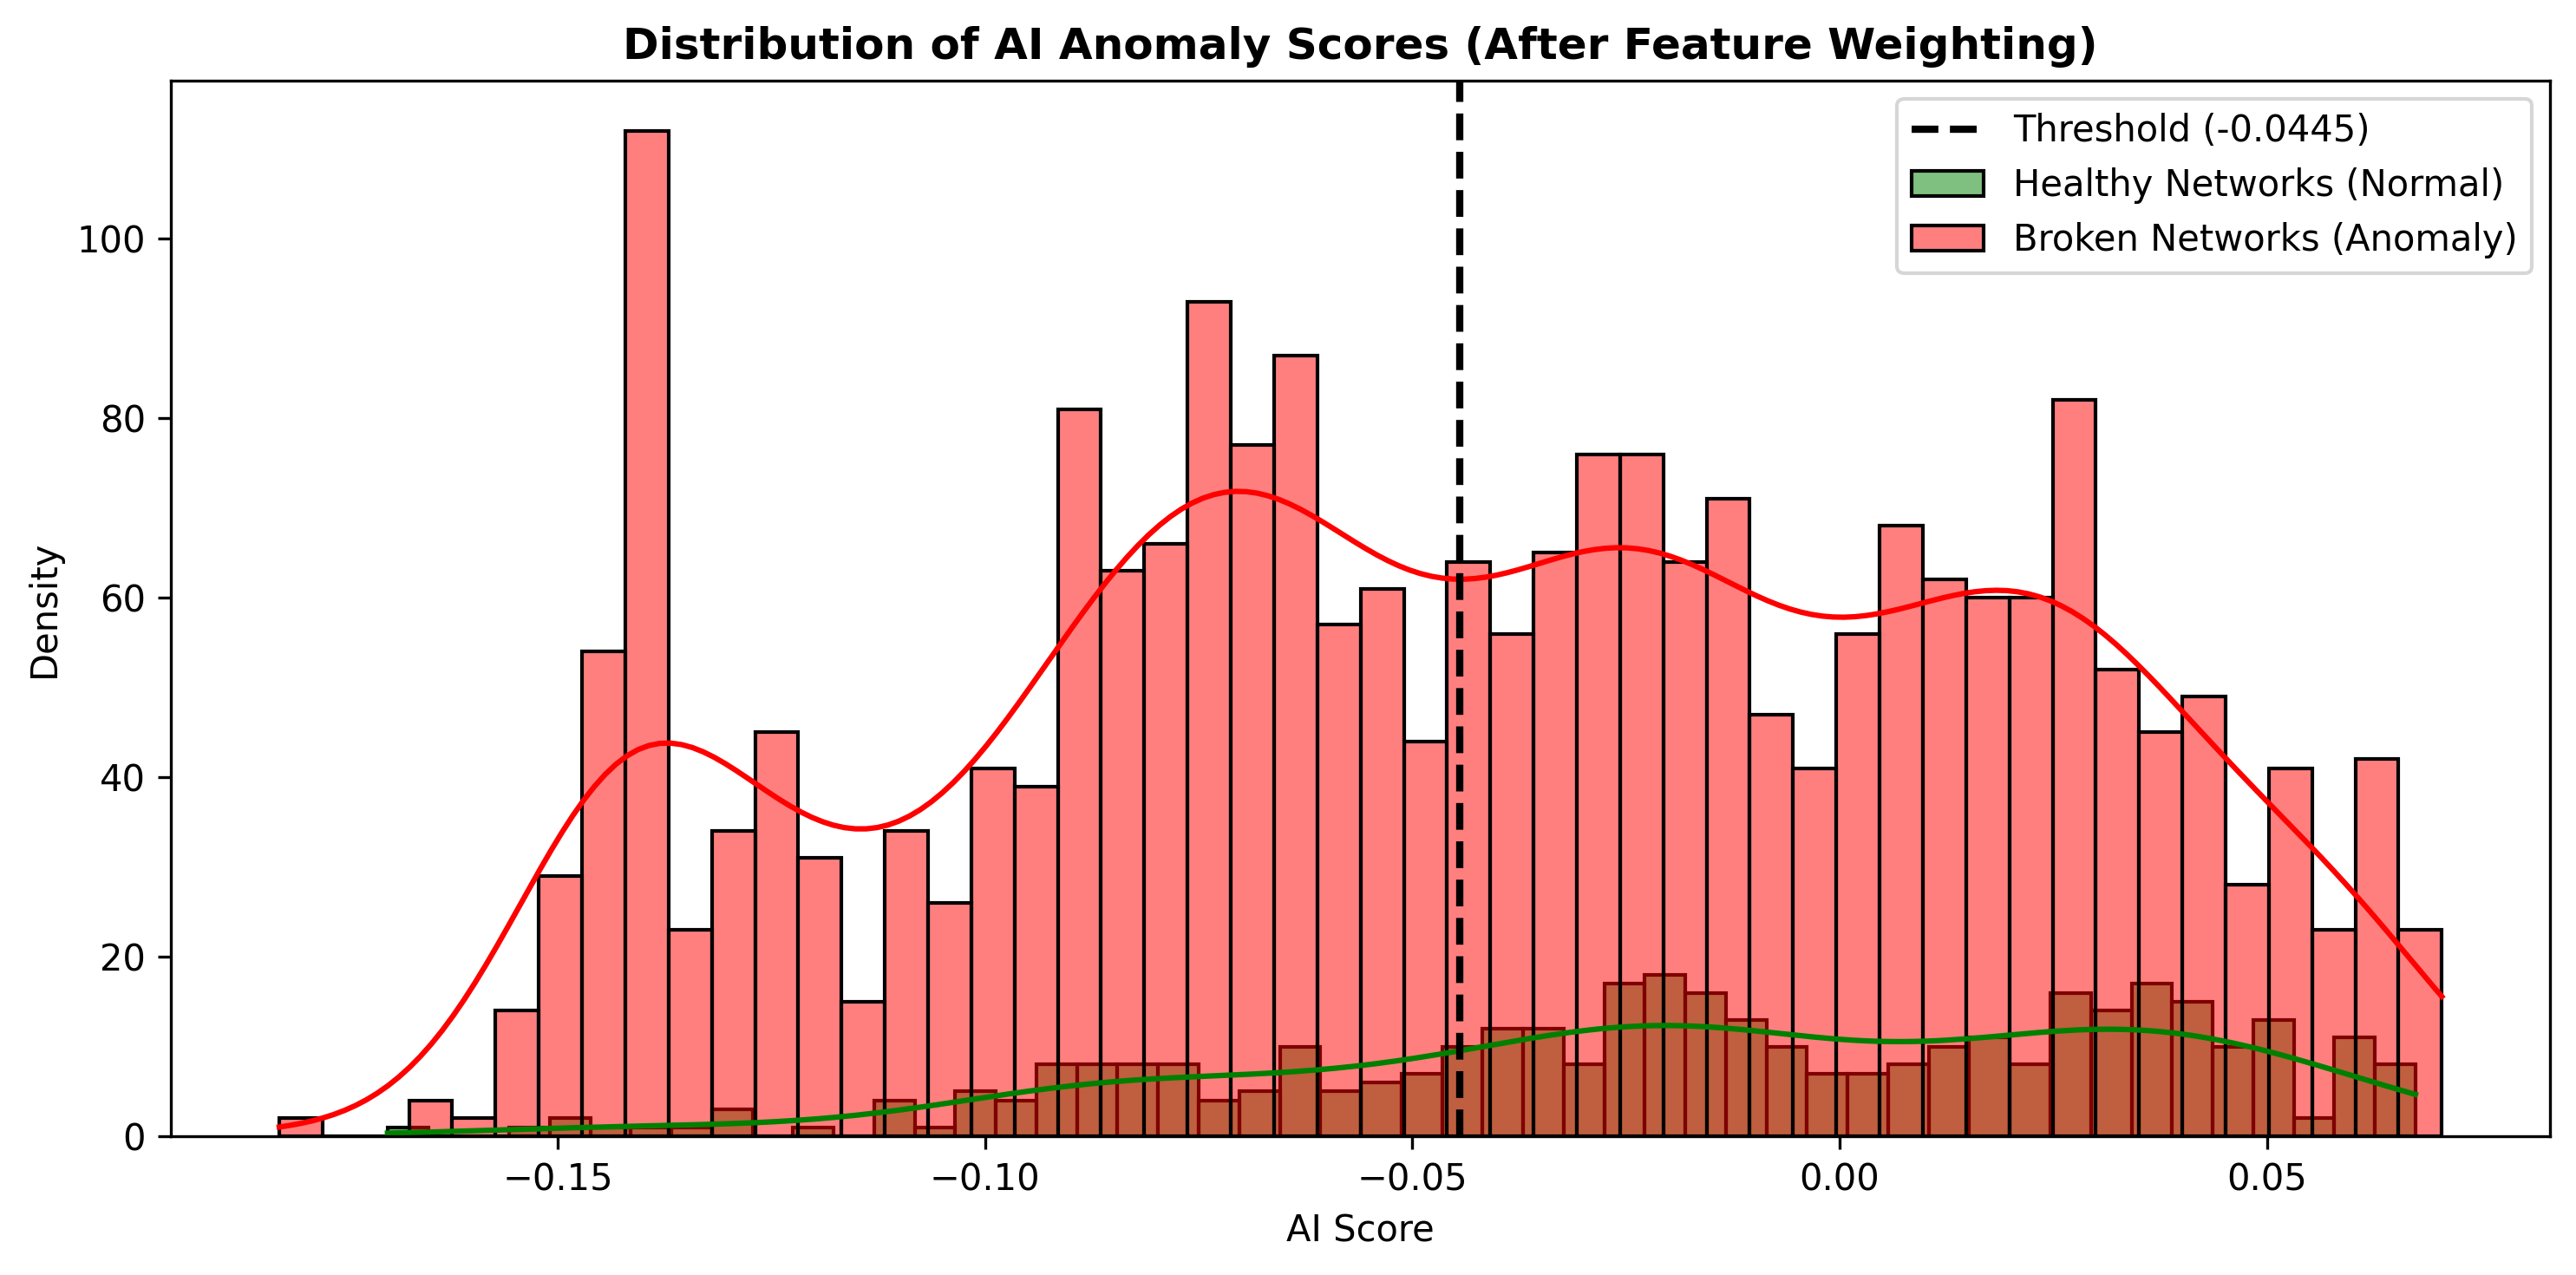

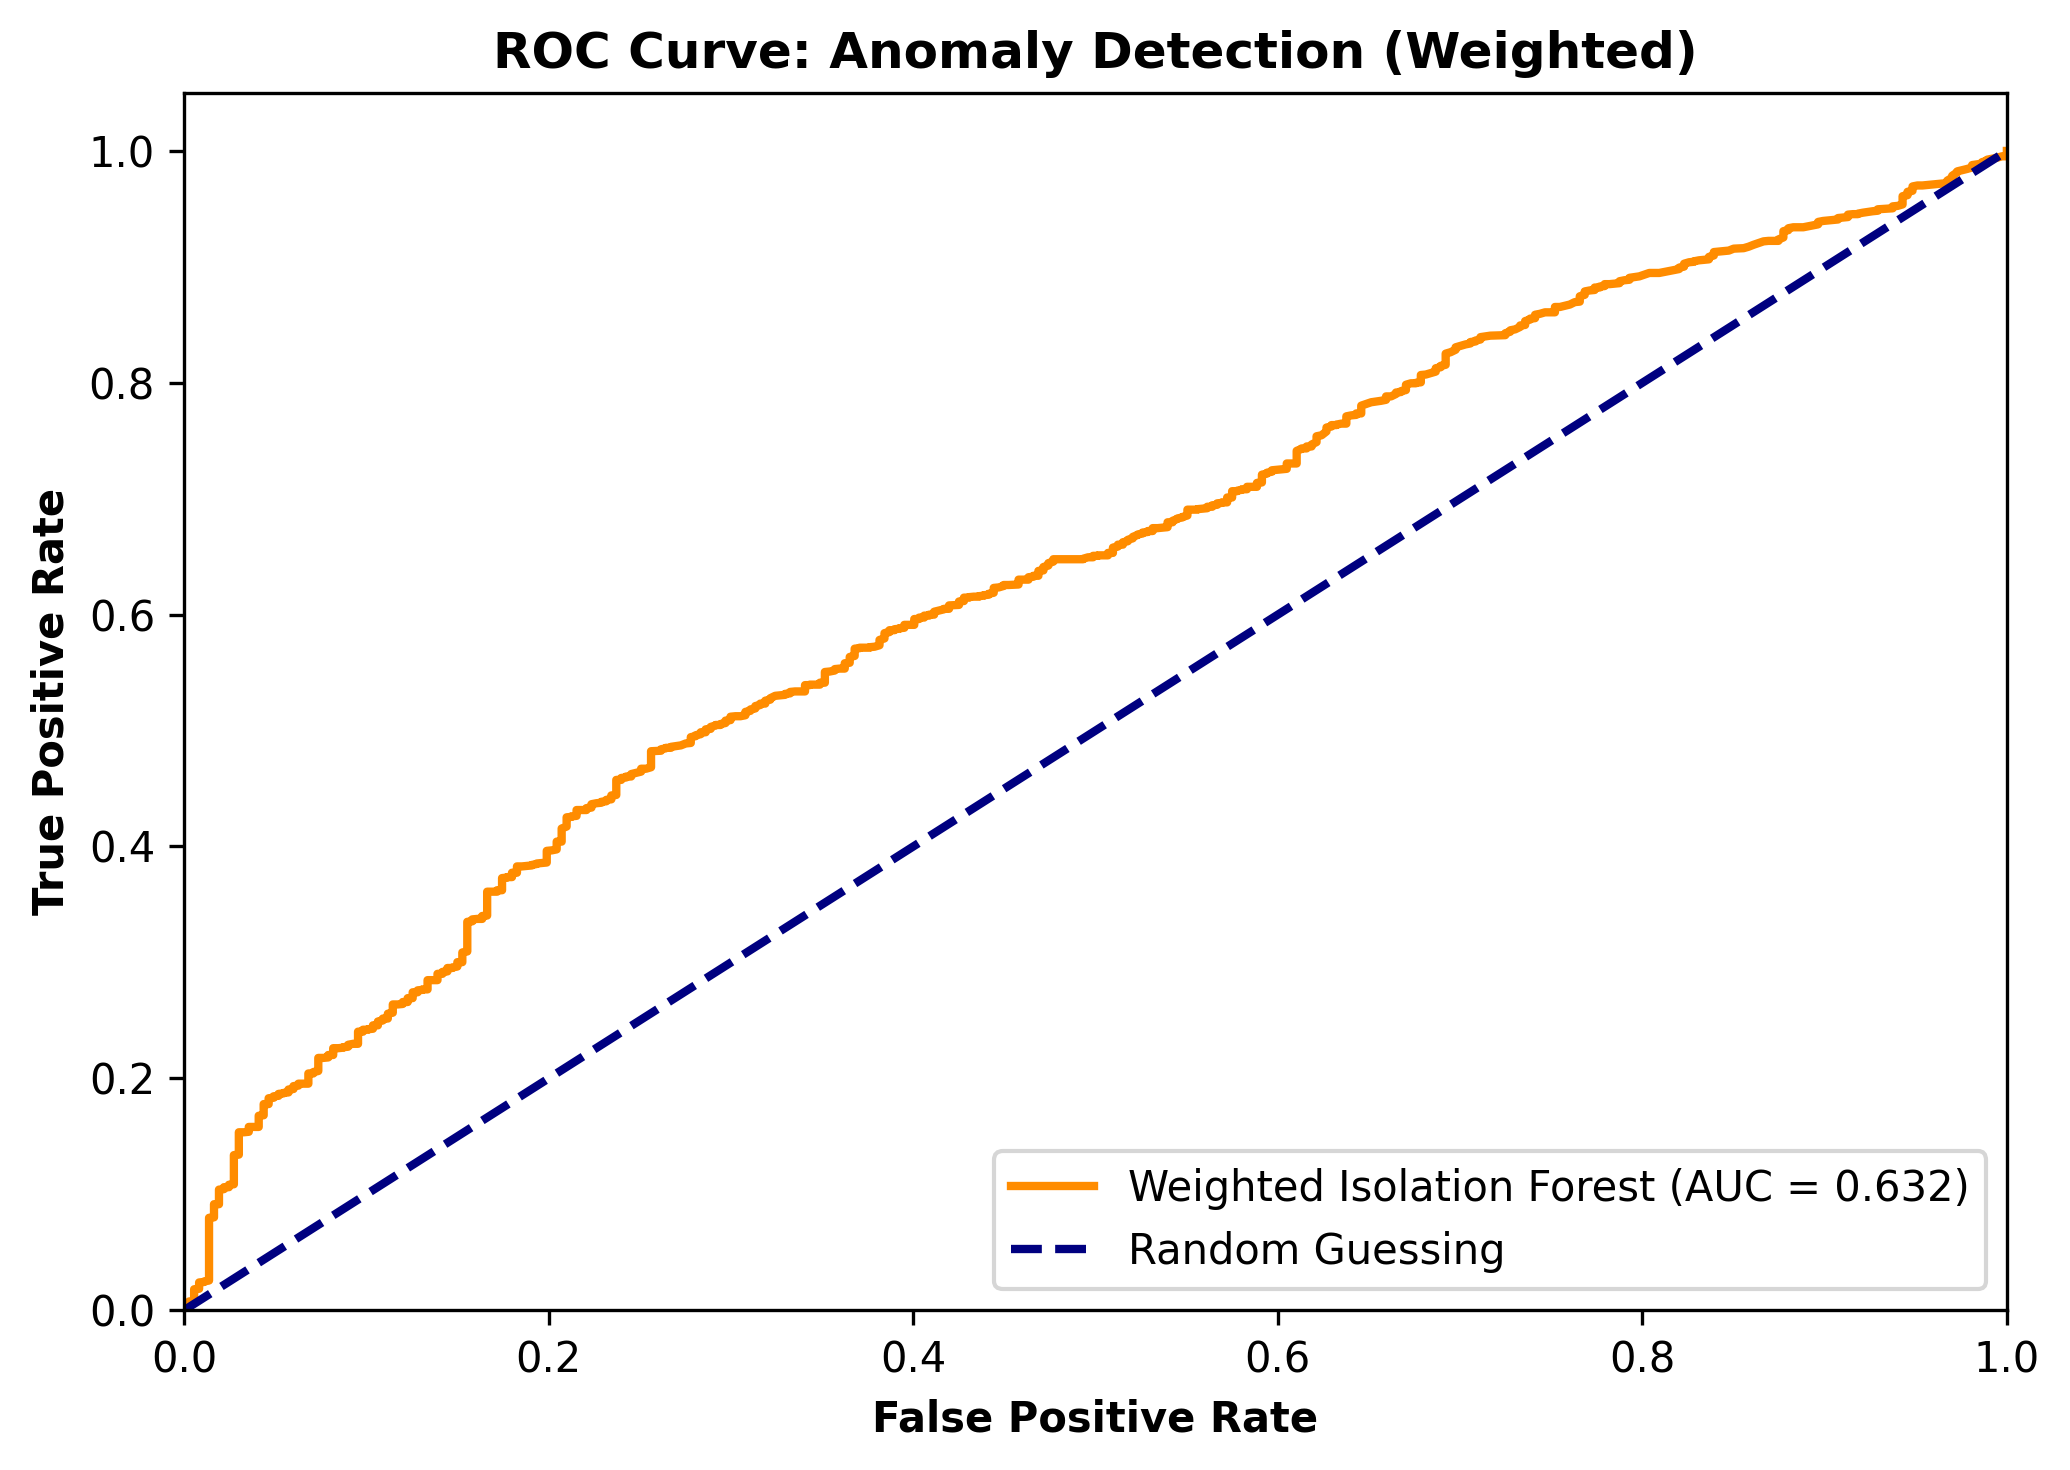


--- ALL STEPS COMPLETED SUCCESSFULLY! ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, balanced_accuracy_score
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network', 'Link_Profile',
                'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B',
                'Risk_Level', 'Error_Type']

features_to_check = df_features.drop(columns=cols_to_drop)


df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)
print(f"Original Records: {len(df_features)} | Cleaned Records: {len(df_clean)}")


print("\n--- STEP 2: DATA SPLITTING (NOVELTY DETECTION) ---")
core_features = [
    'Prefix_A', 'Prefix_B', 'duplicate_ip', 'same_subnet_mask',
    'prefix_difference', 'same_network', 'both_interfaces_up',
    'invalid_host_a', 'invalid_host_b', 'subnet_capacity_a',
    'subnet_capacity_b', 'device_a_degree', 'device_b_degree',
    'subnet_reuse_count'
]

df_normal = df_clean[df_clean['Label'] == 0]
df_anomaly = df_clean[df_clean['Label'] == 1]

normal_train, normal_test = train_test_split(df_normal, test_size=0.20, random_state=42)

df_test_mixed = pd.concat([normal_test, df_anomaly])

X_train = normal_train[core_features]
X_test = df_test_mixed[core_features]
y_test_actual = df_test_mixed['Label']

print(f"Training strictly on {len(X_train)} NORMAL records...")
print(f"Testing on mixed set of {len(X_test)} records ({len(normal_test)} Normal, {len(df_anomaly)} Anomalies)")


print("\n--- STEP 3: APPLYING ARTIFICIAL FEATURE WEIGHTS ---")
X_train_weighted = X_train.copy()
X_test_weighted = X_test.copy()

fatal_features = ['invalid_host_a', 'invalid_host_b', 'duplicate_ip']
for feature in fatal_features:
    X_train_weighted[feature] = X_train_weighted[feature] * 1000
    X_test_weighted[feature] = X_test_weighted[feature] * 1000

suspicious_features = ['same_network', 'same_subnet_mask', 'both_interfaces_up']
for feature in suspicious_features:
    X_train_weighted[feature] = (1 - X_train_weighted[feature]) * 50
    X_test_weighted[feature] = (1 - X_test_weighted[feature]) * 50

print("Weights applied successfully to force AI attention on explicit rules.")

print("\n--- STEP 4: MODEL TRAINING ---")
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_train_weighted)
test_scores = iso_forest.decision_function(X_test_weighted)

print("\n--- STEP 5: OPTIMIZING THRESHOLD ---")
thresholds = np.linspace(-0.2, 0.2, 500)
best_threshold = 0.0
best_balanced_acc = 0.0

for t in thresholds:
    y_pred_temp = (test_scores < t).astype(int)
    current_balanced_acc = balanced_accuracy_score(y_test_actual, y_pred_temp)
    if current_balanced_acc > best_balanced_acc:
        best_balanced_acc = current_balanced_acc
        best_threshold = t

y_pred_best = (test_scores < best_threshold).astype(int)
standard_accuracy = accuracy_score(y_test_actual, y_pred_best)

print(f"Optimal Threshold Found: {best_threshold:.4f}")
print(f"Calibrated Standard Accuracy: {standard_accuracy * 100:.2f}%")
print(f"Calibrated Balanced Accuracy: {best_balanced_acc * 100:.2f}%")

print("\n--- STEP 6: EVALUATION METRICS ---")
cm = confusion_matrix(y_test_actual, y_pred_best)

print(f"True Positives (Caught Errors)     : {cm[1][1]}")
print(f"True Negatives (Correctly Passed)  : {cm[0][0]}")
print(f"False Positives (FALSE ALARMS)     : {cm[0][1]}")
print(f"False Negatives (MISSED ERRORS)    : {cm[1][0]}\n")
print(classification_report(y_test_actual, y_pred_best, target_names=["Normal (0)", "Anomaly (1)"]))

results_df = df_test_mixed.copy()
results_df['Anomaly_Score'] = test_scores
results_df['Predicted_Label'] = y_pred_best
results_df['Is_Correct'] = (results_df['Label'] == results_df['Predicted_Label']).astype(int)
results_df.to_csv('model_test_set_results.csv', index=False)

print("\n--- STEP 7: GENERATING GRAPHICAL EVALUATIONS ---")

plt.figure(figsize=(6, 4), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Isolation Forest Confusion Matrix (Weighted)', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.tight_layout()
plt.savefig('Thesis_Confusion_Matrix_Weighted.png')
plt.show()

plt.figure(figsize=(10, 5), dpi=300)
sns.histplot(test_scores[y_test_actual == 0], color='green', label='Healthy Networks (Normal)', kde=True, bins=50, alpha=0.5)
sns.histplot(test_scores[y_test_actual == 1], color='red', label='Broken Networks (Anomaly)', kde=True, bins=50, alpha=0.5)
plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_threshold:.4f})')
plt.title('Distribution of AI Anomaly Scores (After Feature Weighting)', fontweight='bold')
plt.xlabel('AI Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('Thesis_Score_Overlap_Weighted.png')
plt.show()

inverted_scores = -test_scores
fpr, tpr, _ = roc_curve(y_test_actual, inverted_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Weighted Isolation Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve: Anomaly Detection (Weighted)', fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('Thesis_ROC_Curve_Weighted.png')
plt.show()

print("\n--- ALL STEPS COMPLETED SUCCESSFULLY! ---")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
df_clean = df_features.drop(columns=cols_to_drop)

print("--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---")

categorical_cols = ['Link_Profile', 'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B']

y = df_clean['Label']
error_types = df_clean['Error_Type']

X_raw = df_clean.drop(columns=['Label', 'Risk_Level', 'Error_Type'])
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

print("--- STEP 3: TRAIN & TEST SPLIT ---")
X_train, X_test, y_train, y_test, err_train, err_test = train_test_split(
    X_encoded, y, error_types, test_size=0.20, random_state=42, stratify=y
)

print("--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---\n")

results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Error_Type': err_test
})

actual_anomalies = results_df[results_df['Actual_Label'] == 1]

caught_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 1]
missed_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 0]

print("--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---")
print("These are the errors the Random Forest successfully understood:")
print(caught_errors['Error_Type'].value_counts())

print("\n--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---")
print("These are the errors the Random Forest was 'mathematically blind' to:")
print(missed_errors['Error_Type'].value_counts())

print("\n--- OVERALL CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Positives (Caught)     : {cm[1][1]}")
print(f"True Negatives (Passed)     : {cm[0][0]}")
print(f"False Positives (False Alarm): {cm[0][1]}")
print(f"False Negatives (Missed)    : {cm[1][0]}")

--- STEP 1: LOAD AND CLEAN DATASET ---
--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---
--- STEP 3: TRAIN & TEST SPLIT ---
--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---
--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---

--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---
These are the errors the Random Forest successfully understood:
Error_Type
ip_range_profile_mismatch    62
device_role_mismatch         60
status_mismatch              55
invalid_host_ip              52
subnet_mask_mismatch         51
profile_subnet_mismatch      45
network_mismatch             44
gateway_role_mismatch        40
overlapping_subnet           39
duplicate_ip                 38
duplicate_subnet             34
Name: count, dtype: int64

--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---
These are the errors the Random Forest was 'mathematically blind' to:
Series([], Name: count, dtype: int64)

--- OVERALL CONFUSION MATRIX ---
True Positives (Caught)     : 520
True Negatives (Passed)     : 480
False Positives (False A

--- STEP 1: LOAD AND COMBINE DATASETS ---
Original Dataset Size: 5000 rows

--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---

--- STEP 3: TRAIN & TEST SPLIT ---
Training securely on 4000 records...
Testing on unseen set of 1000 records...

--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---

--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---

--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---
Error_Type
ip_range_profile_mismatch    62
device_role_mismatch         60
status_mismatch              55
invalid_host_ip              52
subnet_mask_mismatch         51
profile_subnet_mismatch      45
network_mismatch             44
gateway_role_mismatch        40
overlapping_subnet           39
duplicate_ip                 38
duplicate_subnet             34
Name: count, dtype: int64

--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---
Zero missed errors! The model caught everything.

--- OVERALL CONFUSION MATRIX ---
True Positives (Caught)        : 520
True Negatives (Passed)        : 480
False Positives (False 

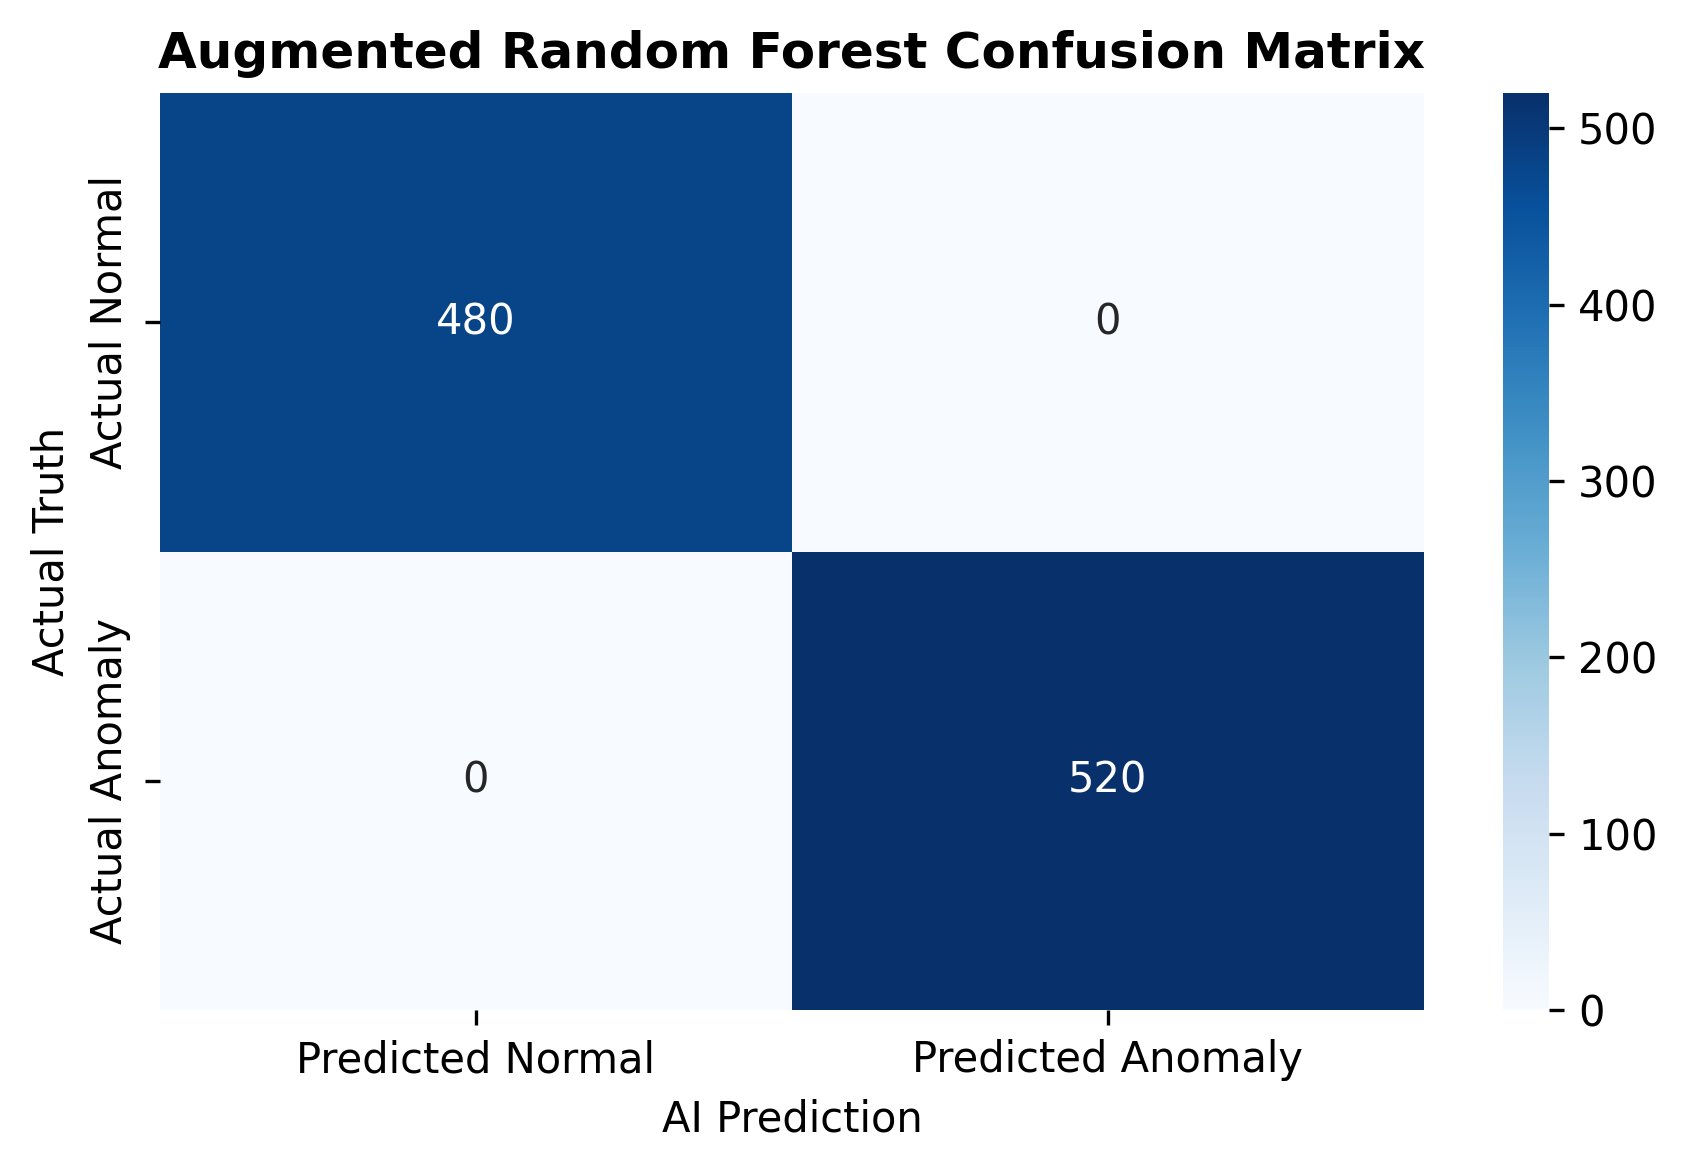

SUCCESS: Model trained on LLM Augmented Dataset and plotted!


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND COMBINE DATASETS ---")
df_original = pd.read_csv('dataset_v5_features.csv')
print(f"Original Dataset Size: {len(df_original)} rows")

try:
    df_llm = pd.read_csv('llm_noisy_data.csv')
    print(f"LLM Noisy Dataset Size: {len(df_llm)} rows")

    df_features = pd.concat([df_original, df_llm], ignore_index=True)
    print(f"Total Combined Dataset Size: {len(df_features)} rows")
except FileNotFoundError:
    print("Warning: llm_noisy_data.csv not found. Using original dataset only.")
    df_features = df_original.copy()

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
df_clean = df_features.drop(columns=cols_to_drop)

print("\n--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---")
categorical_cols = ['Link_Profile', 'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B']

y = df_clean['Label']
error_types = df_clean['Error_Type']

X_raw = df_clean.drop(columns=['Label', 'Risk_Level', 'Error_Type'])
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

print("\n--- STEP 3: TRAIN & TEST SPLIT ---")
X_train, X_test, y_train, y_test, err_train, err_test = train_test_split(
    X_encoded, y, error_types, test_size=0.20, random_state=42, stratify=y
)
print(f"Training securely on {len(X_train)} records...")
print(f"Testing on unseen set of {len(X_test)} records...")

print("\n--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---")

results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Error_Type': err_test
})


actual_anomalies = results_df[results_df['Actual_Label'] == 1]

caught_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 1]
missed_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 0]

print("\n--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---")
print(caught_errors['Error_Type'].value_counts())

print("\n--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---")
if len(missed_errors) == 0:
    print("Zero missed errors! The model caught everything.")
else:
    print(missed_errors['Error_Type'].value_counts())

print("\n--- OVERALL CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Positives (Caught)        : {cm[1][1]}")
print(f"True Negatives (Passed)        : {cm[0][0]}")
print(f"False Positives (False Alarm)  : {cm[0][1]}")
print(f"False Negatives (Missed)       : {cm[1][0]}\n")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Anomaly (1)"]))

print("\n--- STEP 6: GENERATING ACADEMIC PLOTS ---")
plt.figure(figsize=(6, 4), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Augmented Random Forest Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.tight_layout()
plt.savefig('Thesis_RF_Augmented_Confusion_Matrix.png')
plt.show()

print("SUCCESS: Model trained on LLM Augmented Dataset and plotted!")

In [ ]:
csv_data = """Sample_ID,Network,Link_ID,Link_Profile,Device_A_Role,Device_B_Role,Prefix_A,Prefix_B,duplicate_ip,same_subnet_mask,same_network,prefix_difference,both_interfaces_up,invalid_host_a,invalid_host_b,subnet_capacity_a,subnet_capacity_b,host_number_a,host_number_b,gateway_ip_on_non_router,expected_ip_range_match,device_a_degree,device_b_degree,subnet_reuse_count,duplicate_subnet_flag,overlapping_subnet_flag,role_pair_valid,IP_Range_A,IP_Range_B,Label,Risk_Level,Error_Type
1001,OfficeNet,L1001,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,12,11,1,0,0,1,10_private,10_private,0,none,none
1002,CampusNet,L1002,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,10,20,0,1,45,33,1,0,0,1,172_private,172_private,0,none,none
1003,FinanceNet,L1003,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,2,3,0,1,31,18,1,0,0,1,10_private,10_private,0,none,none
1004,RetailNet,L1004,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,9,8,1,0,0,1,192_private,192_private,0,none,none
1005,FactoryNet,L1005,campus_network,Router,Switch,23,23,0,1,1,0,1,0,0,510,510,55,77,0,1,52,40,2,0,0,1,172_private,172_private,0,none,none
1006,GovNet,L1006,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,0,14,14,5,6,0,1,27,14,1,0,0,1,10_private,10_private,0,none,none
1007,EduNet,L1007,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,14,13,1,0,0,1,10_private,10_private,0,none,none
1008,BranchNet,L1008,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,15,25,0,1,48,29,1,0,0,1,192_private,192_private,0,none,none
1009,CloudNet,L1009,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,1,5,0,1,35,22,1,0,0,1,10_private,10_private,0,none,none
1010,MetroNet,L1010,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,16,17,1,0,0,1,172_private,172_private,0,none,none
1011,LabNet,L1011,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,100,110,0,1,39,28,1,0,0,1,10_private,10_private,0,none,none
1012,MediaNet,L1012,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,0,14,14,7,8,0,1,22,19,1,0,0,1,172_private,172_private,0,none,none
1013,ISPNet,L1013,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,20,21,1,0,0,1,10_private,10_private,0,none,none
1014,SalesNet,L1014,campus_network,Router,Switch,23,23,0,1,1,0,1,0,0,510,510,66,67,0,1,43,35,2,0,0,1,172_private,172_private,0,none,none
1015,OpsNet,L1015,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,2,4,0,1,25,16,1,0,0,1,10_private,10_private,0,none,none
1016,CoreNet,L1016,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,18,19,1,0,0,1,192_private,192_private,0,none,none
1017,HQNet,L1017,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,22,23,0,1,51,41,1,0,0,1,10_private,10_private,0,none,none
1018,DataHub,L1018,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,0,14,14,9,10,0,1,24,20,1,0,0,1,172_private,172_private,0,none,none
1019,SiteNet,L1019,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,15,16,1,0,0,1,10_private,10_private,0,none,none
1020,WarehouseNet,L1020,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,30,31,0,1,42,30,1,0,0,1,192_private,192_private,0,none,none
1021,DevNet,L1021,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,3,4,0,1,28,17,1,0,0,1,10_private,10_private,0,none,none
1022,RegionalNet,L1022,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,13,14,1,0,0,1,172_private,172_private,0,none,none
1023,ResearchNet,L1023,campus_network,Router,Switch,23,23,0,1,1,0,1,0,0,510,510,88,99,0,1,47,36,1,0,0,1,10_private,10_private,0,none,none
1024,EdgeNet,L1024,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,0,14,14,11,12,0,1,26,18,1,0,0,1,172_private,172_private,0,none,none
1025,TransitNet,L1025,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,17,18,1,0,0,1,10_private,10_private,0,none,none
1026,AnomalyNet,L1026,router_to_router,Router,Router,30,24,0,0,1,6,1,0,0,2,254,1,10,0,1,12,11,1,0,0,1,10_private,10_private,1,high,subnet_mask_mismatch
1027,AnomalyNet,L1027,router_to_router,Router,Router,30,29,0,0,1,1,1,0,0,2,6,1,2,0,1,13,12,1,0,0,1,10_private,10_private,1,medium,profile_subnet_mismatch
1028,AnomalyNet,L1028,campus_network,Router,Switch,24,24,1,1,1,0,1,0,0,254,254,15,15,0,1,40,30,1,0,0,1,172_private,172_private,1,high,duplicate_ip
1029,AnomalyNet,L1029,datacenter_segment,Switch,Server,29,29,0,1,1,0,0,0,0,6,6,2,3,0,1,25,20,1,0,0,1,10_private,10_private,1,medium,status_mismatch
1030,AnomalyNet,L1030,campus_network,Router,Switch,24,24,0,1,1,0,1,1,0,254,254,0,20,0,1,42,32,1,0,0,1,192_private,192_private,1,high,invalid_host_ip
1031,AnomalyNet,L1031,datacenter_segment,Switch,Server,24,24,0,1,1,0,1,0,1,254,254,10,255,0,1,33,22,1,0,0,1,10_private,10_private,1,high,invalid_host_ip
1032,AnomalyNet,L1032,datacenter_segment,Firewall,PC,24,24,0,1,1,0,1,0,0,254,254,5,6,0,1,18,1,1,0,0,0,172_private,172_private,1,medium,device_role_mismatch
1033,AnomalyNet,L1033,router_to_router,Router,Router,30,30,0,1,1,0,0,0,0,2,2,1,2,0,1,14,15,1,0,0,1,10_private,10_private,1,medium,status_mismatch
1034,AnomalyNet,L1034,campus_network,Router,Switch,23,23,1,1,1,0,1,0,0,510,510,44,44,0,1,46,35,2,0,0,1,172_private,172_private,1,high,duplicate_ip
1035,AnomalyNet,L1035,router_to_router,Router,Router,30,24,0,0,1,6,1,0,0,2,254,1,5,0,1,11,10,1,0,0,1,192_private,192_private,1,high,subnet_mask_mismatch
1036,AnomalyNet,L1036,datacenter_segment,Firewall,PC,29,29,0,1,1,0,1,0,0,6,6,1,2,0,1,20,2,1,0,0,0,10_private,10_private,1,medium,device_role_mismatch
1037,AnomalyNet,L1037,campus_network,Router,Switch,24,24,0,1,1,0,0,0,0,254,254,12,13,0,1,44,31,1,0,0,1,172_private,172_private,1,medium,status_mismatch
1038,AnomalyNet,L1038,router_to_router,Router,Router,30,29,0,0,1,1,1,0,0,2,6,1,2,0,1,10,9,1,0,0,1,10_private,10_private,1,medium,profile_subnet_mismatch
1039,AnomalyNet,L1039,campus_network,Router,Switch,24,24,0,1,1,0,1,1,0,254,254,0,30,0,1,38,27,1,0,0,1,192_private,192_private,1,high,invalid_host_ip
1040,AnomalyNet,L1040,datacenter_segment,Switch,Server,29,29,1,1,1,0,1,0,0,6,6,3,3,0,1,24,19,1,0,0,1,10_private,10_private,1,high,duplicate_ip
1041,AnomalyNet,L1041,router_to_router,Router,Router,30,24,0,0,1,6,1,0,0,2,254,1,6,0,1,16,17,1,0,0,1,172_private,172_private,1,high,subnet_mask_mismatch
1042,AnomalyNet,L1042,datacenter_segment,Firewall,PC,24,24,0,1,1,0,1,0,0,254,254,8,9,0,1,19,3,1,0,0,0,172_private,172_private,1,medium,device_role_mismatch
1043,AnomalyNet,L1043,campus_network,Router,Switch,23,23,0,1,1,0,0,0,0,510,510,50,60,0,1,41,29,2,0,0,1,10_private,10_private,1,medium,status_mismatch
1044,AnomalyNet,L1044,router_to_router,Router,Router,30,29,0,0,1,1,1,0,0,2,6,1,2,0,1,12,13,1,0,0,1,10_private,10_private,1,medium,profile_subnet_mismatch
1045,AnomalyNet,L1045,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,1,14,14,4,15,0,1,27,21,1,0,0,1,172_private,172_private,1,high,invalid_host_ip
1046,AnomalyNet,L1046,campus_network,Router,Switch,24,24,1,1,1,0,1,0,0,254,254,70,70,0,1,43,34,1,0,0,1,192_private,192_private,1,high,duplicate_ip
1047,AnomalyNet,L1047,router_to_router,Router,Router,30,24,0,0,1,6,1,0,0,2,254,1,7,0,1,15,14,1,0,0,1,10_private,10_private,1,high,subnet_mask_mismatch
1048,AnomalyNet,L1048,datacenter_segment,Firewall,PC,29,29,0,1,1,0,1,0,0,6,6,2,3,0,1,21,2,1,0,0,0,10_private,10_private,1,medium,device_role_mismatch
1049,AnomalyNet,L1049,campus_network,Router,Switch,24,24,0,1,1,0,0,0,0,254,254,90,91,0,1,39,26,1,0,0,1,172_private,172_private,1,medium,status_mismatch
1050,AnomalyNet,L1050,datacenter_segment,Switch,Server,29,29,1,1,1,0,1,0,0,6,6,5,5,0,1,23,18,1,0,0,1,10_private,10_private,1,high,duplicate_ip"""

with open('llm_noisy_data.csv', 'w') as f:
    f.write(csv_data)

print("SUCCESS: 'llm_noisy_data.csv' has been created in your workspace!")

SUCCESS: 'llm_noisy_data.csv' has been created in your workspace!


--- STEP 1: LOAD AND COMBINE DATASETS ---
Original Dataset Size: 5000 rows
LLM Noisy Dataset Size: 50 rows
Total Combined Dataset Size: 5050 rows

--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---

--- STEP 3: TRAIN & TEST SPLIT ---
Training securely on 4040 records...
Testing on unseen set of 1010 records...

--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---

--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---

--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---
Error_Type
ip_range_profile_mismatch    58
device_role_mismatch         56
status_mismatch              54
profile_subnet_mismatch      52
invalid_host_ip              51
gateway_role_mismatch        49
subnet_mask_mismatch         48
network_mismatch             44
duplicate_ip                 41
overlapping_subnet           36
duplicate_subnet             36
Name: count, dtype: int64

--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---
Zero missed errors! The model caught everything.

--- OVERALL CONFUSION MATRIX ---
True Positives (Caught)   

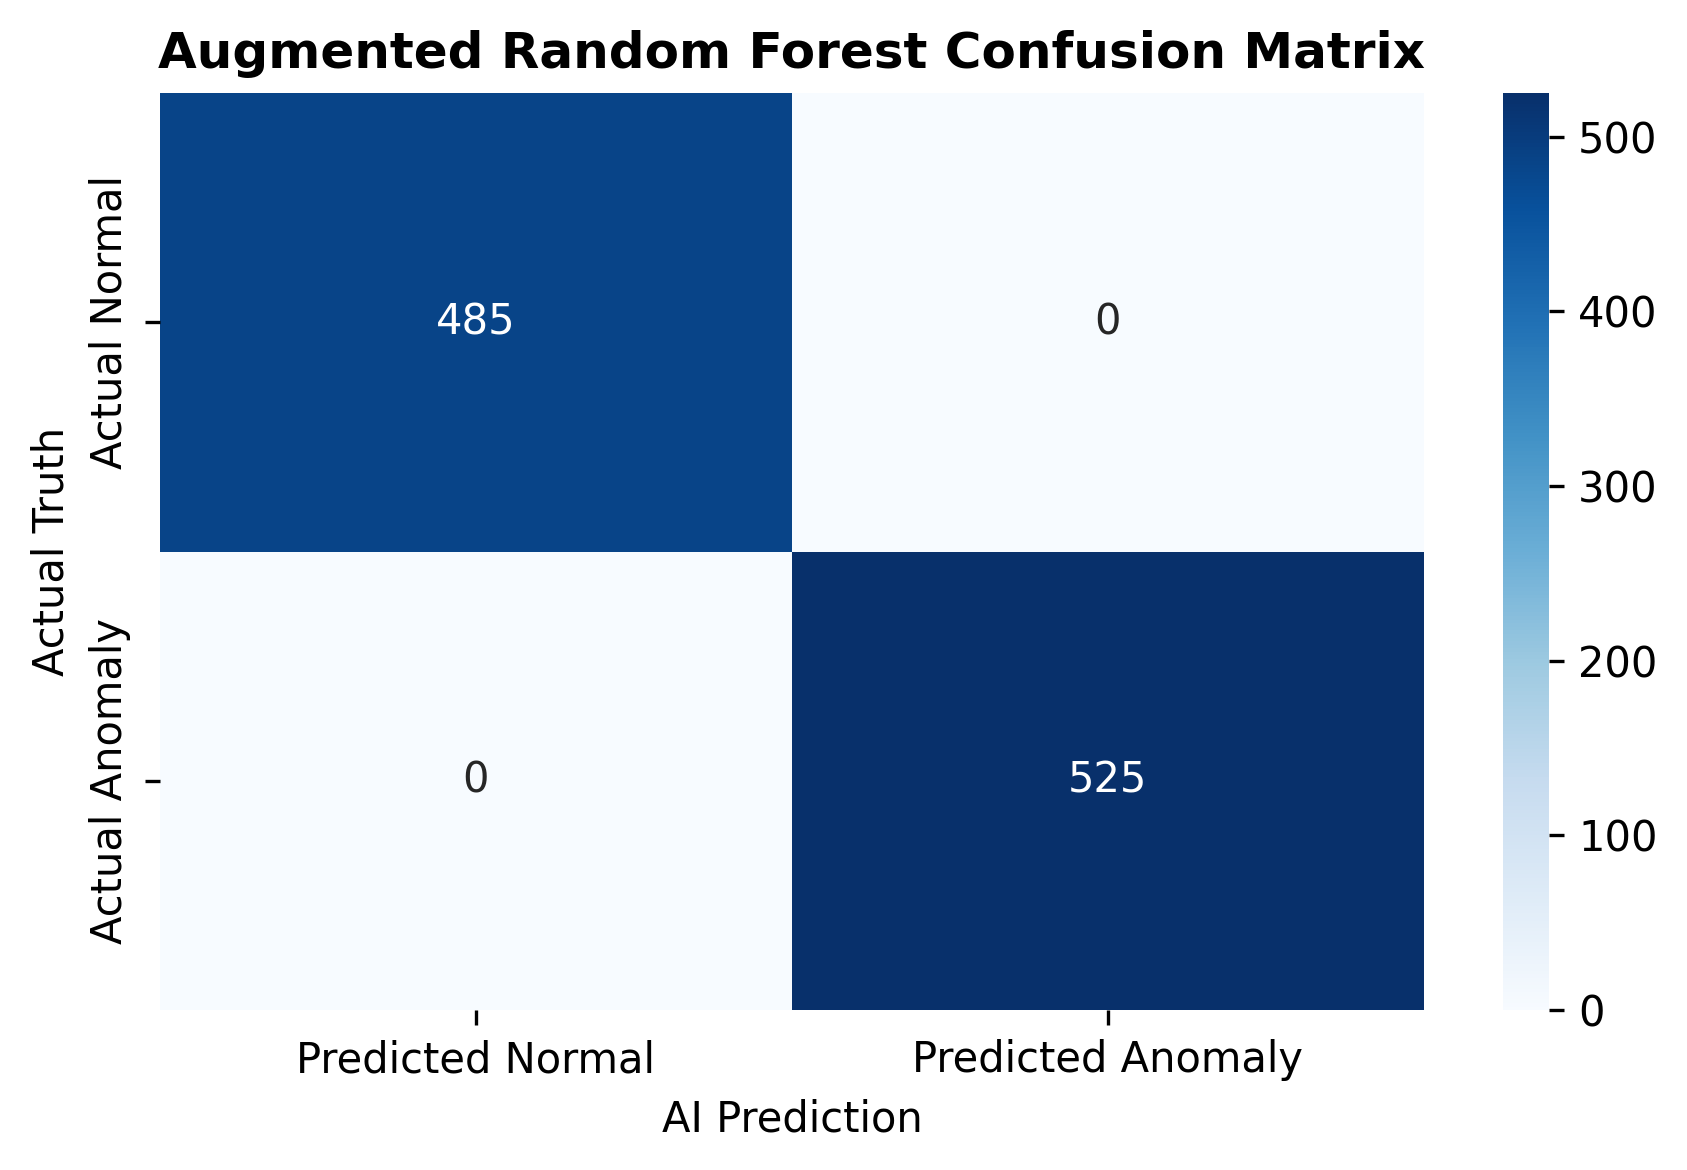

SUCCESS: Model trained on LLM Augmented Dataset and plotted!


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND COMBINE DATASETS ---")
df_original = pd.read_csv('dataset_v5_features.csv')
print(f"Original Dataset Size: {len(df_original)} rows")

try:
    df_llm = pd.read_csv('llm_noisy_data.csv')
    print(f"LLM Noisy Dataset Size: {len(df_llm)} rows")


    df_features = pd.concat([df_original, df_llm], ignore_index=True)
    print(f"Total Combined Dataset Size: {len(df_features)} rows")
except FileNotFoundError:
    print("Warning: llm_noisy_data.csv not found. Using original dataset only.")
    df_features = df_original.copy()


cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
df_clean = df_features.drop(columns=cols_to_drop)

print("\n--- STEP 2: PREPARE FEATURES FOR RANDOM FOREST ---")
categorical_cols = ['Link_Profile', 'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B']

y = df_clean['Label']
error_types = df_clean['Error_Type']

X_raw = df_clean.drop(columns=['Label', 'Risk_Level', 'Error_Type'])
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

print("\n--- STEP 3: TRAIN & TEST SPLIT ---")
X_train, X_test, y_train, y_test, err_train, err_test = train_test_split(
    X_encoded, y, error_types, test_size=0.20, random_state=42, stratify=y
)
print(f"Training securely on {len(X_train)} records...")
print(f"Testing on unseen set of {len(X_test)} records...")

print("\n--- STEP 4: TRAIN SUPERVISED RANDOM FOREST ---")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n--- STEP 5: ANALYZE ALGORITHM BLINDNESS ---")

results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Error_Type': err_test
})

actual_anomalies = results_df[results_df['Actual_Label'] == 1]

caught_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 1]
missed_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 0]

print("\n--- CAUGHT ERRORS BY TYPE (TRUE POSITIVES) ---")
print(caught_errors['Error_Type'].value_counts())

print("\n--- MISSED ERRORS BY TYPE (FALSE NEGATIVES) ---")
if len(missed_errors) == 0:
    print("Zero missed errors! The model caught everything.")
else:
    print(missed_errors['Error_Type'].value_counts())

print("\n--- OVERALL CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Positives (Caught)        : {cm[1][1]}")
print(f"True Negatives (Passed)        : {cm[0][0]}")
print(f"False Positives (False Alarm)  : {cm[0][1]}")
print(f"False Negatives (Missed)       : {cm[1][0]}\n")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Anomaly (1)"]))

print("\n--- STEP 6: GENERATING ACADEMIC PLOTS ---")
plt.figure(figsize=(6, 4), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Augmented Random Forest Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.tight_layout()
plt.savefig('Thesis_RF_Augmented_Confusion_Matrix.png')
plt.show()

print("SUCCESS: Model trained on LLM Augmented Dataset and plotted!")

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: CREATING CLAUDE CSV FILE ---")
claude_csv_data = """Sample_ID,Network,Link_ID,Link_Profile,Device_A_Role,Device_B_Role,Prefix_A,Prefix_B,duplicate_ip,same_subnet_mask,same_network,prefix_difference,both_interfaces_up,invalid_host_a,invalid_host_b,subnet_capacity_a,subnet_capacity_b,host_number_a,host_number_b,gateway_ip_on_non_router,expected_ip_range_match,device_a_degree,device_b_degree,subnet_reuse_count,duplicate_subnet_flag,overlapping_subnet_flag,role_pair_valid,IP_Range_A,IP_Range_B,Label,Risk_Level,Error_Type
1001,CorpNet,L1001,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,12,8,1,0,0,1,10_private,10_private,0,Low,none
1002,BranchNet,L1002,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,1,15,0,1,45,22,1,0,0,1,192_private,192_private,0,Low,none
1003,DatacenterA,L1003,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,3,5,0,1,30,18,1,0,0,1,10_private,10_private,0,Low,none
1004,OfficeNet,L1004,campus_network,Router,Switch,23,23,0,1,1,0,1,0,0,510,510,100,200,0,1,60,35,1,0,0,1,172_private,172_private,0,Low,none
1005,FinanceNet,L1005,datacenter_segment,Switch,Server,28,28,0,1,1,0,1,0,0,14,14,5,10,0,1,20,14,1,0,0,1,10_private,10_private,0,Low,none
1006,WanLink,L1006,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,9,7,2,0,0,1,172_private,172_private,0,Low,none
1007,MgmtNet,L1007,campus_network,Switch,Server,26,26,0,1,1,0,1,0,0,62,62,10,20,0,1,25,12,1,0,0,1,10_private,10_private,0,Low,none
1008,ProdNet,L1008,datacenter_segment,Firewall,Server,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,18,9,1,0,0,1,10_private,10_private,0,Low,none
1009,HRNet,L1009,campus_network,Router,Switch,25,25,0,1,1,0,1,0,0,126,126,50,80,0,1,40,19,1,0,0,1,192_private,192_private,0,Low,none
1010,DevNet,L1010,datacenter_segment,Switch,Server,27,27,0,1,1,0,1,0,0,30,30,12,25,0,1,22,11,1,0,0,1,10_private,10_private,0,Low,none
1011,CorpNet,L1011,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,14,6,1,0,0,1,10_private,10_private,0,Low,none
1012,BranchNet,L1012,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,5,100,0,1,55,28,2,0,0,1,192_private,192_private,0,Low,none
1013,StorageNet,L1013,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,0,0,6,6,2,4,0,1,16,8,1,0,0,1,10_private,10_private,0,Low,none
1014,WanLink,L1014,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,11,5,3,0,0,1,172_private,172_private,0,Low,none
1015,SalesNet,L1015,campus_network,Router,Switch,24,24,0,1,1,0,1,0,0,254,254,20,150,0,1,48,23,1,0,0,1,192_private,192_private,0,Low,none
1016,OfficeNet,L1016,campus_network,Switch,Server,26,26,0,1,1,0,1,0,0,62,62,15,30,0,1,28,14,1,0,0,1,172_private,172_private,0,Low,none
1017,DatacenterB,L1017,datacenter_segment,Firewall,Server,28,28,0,1,1,0,1,0,0,14,14,3,8,0,1,19,10,1,0,0,1,10_private,10_private,0,Low,none
1018,MgmtNet,L1018,campus_network,Router,Switch,25,25,0,1,1,0,1,0,0,126,126,60,90,0,1,35,17,2,0,0,1,192_private,192_private,0,Low,none
1019,ProdNet,L1019,datacenter_segment,Switch,Server,27,27,0,1,1,0,1,0,0,30,30,8,22,0,1,24,13,1,0,0,1,10_private,10_private,0,Low,none
1020,DevNet,L1020,router_to_router,Router,Router,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,10,6,2,0,0,1,172_private,172_private,0,Low,none
1021,CorpNet,L1021,router_to_router,Router,Router,30,24,0,0,0,6,1,0,0,2,254,1,50,0,0,12,8,1,0,0,1,10_private,10_private,1,High,subnet_mask_mismatch
1022,BranchNet,L1022,campus_network,Router,Switch,24,24,1,1,1,0,1,0,0,254,254,10,10,0,1,45,22,1,1,0,1,192_private,192_private,1,High,duplicate_ip
1023,DatacenterA,L1023,datacenter_segment,Firewall,PC,29,29,0,1,1,0,1,0,0,6,6,3,5,0,1,30,18,1,0,0,0,10_private,10_private,1,Medium,device_role_mismatch
1024,OfficeNet,L1024,campus_network,Router,Switch,23,23,0,1,1,0,0,0,0,510,510,100,200,0,1,60,35,1,0,0,1,172_private,172_private,1,Medium,status_mismatch
1025,FinanceNet,L1025,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,1,0,6,6,0,5,0,1,20,14,1,0,0,1,10_private,10_private,1,High,invalid_host_ip
1026,WanLink,L1026,router_to_router,Router,Router,30,29,0,0,0,1,1,0,0,2,6,1,3,0,0,9,7,2,0,0,1,172_private,172_private,1,High,subnet_mask_mismatch
1027,MgmtNet,L1027,campus_network,Switch,Server,26,24,0,0,0,2,1,0,0,62,254,10,20,0,0,25,12,1,0,1,1,10_private,10_private,1,High,profile_subnet_mismatch
1028,ProdNet,L1028,datacenter_segment,Switch,PC,30,30,0,1,1,0,1,0,0,2,2,1,2,0,1,18,9,1,0,0,0,10_private,10_private,1,Medium,device_role_mismatch
1029,HRNet,L1029,campus_network,Router,Switch,25,25,1,1,1,0,1,0,0,126,126,50,50,0,1,40,19,1,1,0,1,192_private,192_private,1,High,duplicate_ip
1030,DevNet,L1030,datacenter_segment,Switch,Server,27,27,0,1,1,0,1,0,1,30,30,12,255,0,1,22,11,1,0,0,1,10_private,10_private,1,High,invalid_host_ip
1031,StorageNet,L1031,router_to_router,Router,Router,30,24,0,0,0,6,1,0,0,2,254,1,100,0,0,14,6,1,0,0,1,10_private,192_private,1,High,subnet_mask_mismatch
1032,BranchNet,L1032,campus_network,Router,Switch,24,24,0,1,1,0,0,0,0,254,254,5,100,0,1,55,28,2,0,0,1,192_private,192_private,1,Medium,status_mismatch
1033,DatacenterB,L1033,datacenter_segment,Router,Server,28,28,0,1,1,0,1,0,0,14,14,0,8,0,1,19,10,1,0,0,1,10_private,10_private,1,High,invalid_host_ip
1034,SalesNet,L1034,campus_network,Switch,PC,24,24,0,1,1,0,1,0,0,254,254,20,150,0,1,48,23,1,0,0,0,192_private,192_private,1,Medium,device_role_mismatch
1035,WanLink,L1035,router_to_router,Router,Router,30,30,1,1,1,0,1,0,0,2,2,2,2,0,1,11,5,3,1,0,1,172_private,172_private,1,High,duplicate_ip
1036,MgmtNet,L1036,campus_network,Router,Switch,25,29,0,0,0,4,1,0,0,126,6,60,4,0,0,35,17,2,0,0,1,192_private,10_private,1,High,subnet_mask_mismatch
1037,ProdNet,L1037,datacenter_segment,Switch,Server,27,27,0,1,1,0,0,0,0,30,30,8,22,0,1,24,13,1,0,0,1,10_private,10_private,1,Medium,status_mismatch
1038,CorpNet,L1038,campus_network,Firewall,PC,26,26,0,1,1,0,1,0,0,62,62,15,30,0,1,28,14,1,0,0,0,172_private,172_private,1,Medium,device_role_mismatch
1039,DatacenterA,L1039,datacenter_segment,Switch,Server,29,29,0,1,1,0,1,1,0,6,6,0,4,0,1,16,8,1,0,0,1,10_private,10_private,1,High,invalid_host_ip
1040,HRNet,L1040,router_to_router,Router,Router,30,28,0,0,0,2,1,0,0,2,14,1,5,0,0,10,6,2,0,0,1,172_private,172_private,1,High,subnet_mask_mismatch
1041,DevNet,L1041,datacenter_segment,Switch,Server,27,27,1,1,1,0,1,0,0,30,30,18,18,0,1,22,11,1,1,0,1,10_private,10_private,1,High,duplicate_ip
1042,FinanceNet,L1042,campus_network,Router,Switch,24,24,0,1,1,0,0,0,0,254,254,30,120,0,1,50,25,1,0,0,1,192_private,192_private,1,Medium,status_mismatch
1043,SalesNet,L1043,datacenter_segment,Switch,PC,29,29,0,1,1,0,1,0,0,6,6,2,5,0,1,18,9,1,0,0,0,10_private,10_private,1,Medium,device_role_mismatch
1044,BranchNet,L1044,router_to_router,Router,Router,30,30,0,1,1,0,1,0,1,2,2,1,255,0,1,9,7,2,0,0,1,172_private,172_private,1,High,invalid_host_ip
1045,ProdNet,L1045,datacenter_segment,Switch,Server,28,26,0,0,0,2,1,0,0,14,62,5,20,0,0,19,10,1,0,1,1,10_private,10_private,1,High,profile_subnet_mismatch
1046,StorageNet,L1046,campus_network,Router,Switch,23,23,1,1,1,0,1,0,0,510,510,75,75,0,1,40,20,1,1,0,1,172_private,172_private,1,High,duplicate_ip
1047,MgmtNet,L1047,datacenter_segment,Router,Server,29,29,0,1,1,0,1,1,1,6,6,0,255,0,1,25,12,1,0,0,1,10_private,10_private,1,High,invalid_host_ip
1048,WanLink,L1048,router_to_router,Router,Router,30,30,0,1,1,0,0,0,0,2,2,1,2,0,1,14,6,3,0,0,1,172_private,172_private,1,Medium,status_mismatch
1049,CorpNet,L1049,campus_network,Switch,PC,24,24,0,1,1,0,1,0,0,254,254,80,160,0,1,60,35,1,0,0,0,192_private,192_private,1,Medium,device_role_mismatch
1050,DatacenterB,L1050,datacenter_segment,Switch,Server,29,24,0,0,0,5,1,0,0,6,254,3,100,0,0,16,8,1,0,1,1,10_private,192_private,1,High,subnet_mask_mismatch"""

with open('claude_noisy_data.csv', 'w') as f:
    f.write(claude_csv_data)
print("File 'claude_noisy_data.csv' created successfully.\n")

print("--- STEP 2: LOADING AND PREPARING UNSEEN DATA ---")
df_claude = pd.read_csv('claude_noisy_data.csv')
print(f"Loaded {len(df_claude)} rows of Claude AI synthetic data.")

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network']
df_claude_clean = df_claude.drop(columns=[col for col in cols_to_drop if col in df_claude.columns])

y_test_claude = df_claude_clean['Label']
err_test_claude = df_claude_clean['Error_Type']

categorical_cols = ['Link_Profile', 'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B']
X_claude_raw = df_claude_clean.drop(columns=['Label', 'Risk_Level', 'Error_Type'])
X_claude_encoded = pd.get_dummies(X_claude_raw, columns=categorical_cols, drop_first=True)

print("\n--- STEP 3: ALIGNING FEATURES FOR THE TRAINED MODEL ---")
try:
    expected_features = rf_model.feature_names_in_
    X_claude_aligned = X_claude_encoded.reindex(columns=expected_features, fill_value=0)
    print("Features aligned successfully with the model in memory.")
except NameError:
    print("\nERROR: 'rf_model' is not in memory. Please make sure you ran the cell that trained the Random Forest first!")
    raise

print("\n--- STEP 4: RUNNING PREDICTIONS ON EXISTING MODEL ---")
y_pred_claude = rf_model.predict(X_claude_aligned)

print("\n--- RESULTS: DID THE AI CATCH CLAUDE'S ZERO-DAY NOISE? ---")
results_df = pd.DataFrame({
    'Actual_Label': y_test_claude,
    'Predicted_Label': y_pred_claude,
    'Error_Type': err_test_claude
})

actual_anomalies = results_df[results_df['Actual_Label'] == 1]
caught_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 1]
missed_errors = actual_anomalies[actual_anomalies['Predicted_Label'] == 0]

print(f"Total Claude AI Anomalies Introduced : {len(actual_anomalies)}")
print(f"Total Successfully Caught by AI      : {len(caught_errors)}")
print(f"Total MISSED by AI (Zero-Day)        : {len(missed_errors)}\n")

if len(missed_errors) > 0:
    print("--- THE ZERO-DAY ERRORS THE AI MISSED ---")
    print(missed_errors['Error_Type'].value_counts())
else:
    print("Incredible! The AI caught 100% of Claude's unseen anomalies!")

print("\n--- CLAUDE AI HOLD-OUT CONFUSION MATRIX ---")
cm = confusion_matrix(y_test_claude, y_pred_claude)
print(f"True Positives (Caught)        : {cm[1][1]}")
print(f"True Negatives (Passed)        : {cm[0][0]}")
print(f"False Positives (False Alarm)  : {cm[0][1]}")
print(f"False Negatives (Missed)       : {cm[1][0]}")

--- STEP 1: CREATING CLAUDE CSV FILE ---
File 'claude_noisy_data.csv' created successfully.

--- STEP 2: LOADING AND PREPARING UNSEEN DATA ---
Loaded 50 rows of Claude AI synthetic data.

--- STEP 3: ALIGNING FEATURES FOR THE TRAINED MODEL ---
Features aligned successfully with the model in memory.

--- STEP 4: RUNNING PREDICTIONS ON EXISTING MODEL ---

--- RESULTS: DID THE AI CATCH CLAUDE'S ZERO-DAY NOISE? ---
Total Claude AI Anomalies Introduced : 30
Total Successfully Caught by AI      : 29
Total MISSED by AI (Zero-Day)        : 1

--- THE ZERO-DAY ERRORS THE AI MISSED ---
Error_Type
invalid_host_ip    1
Name: count, dtype: int64

--- CLAUDE AI HOLD-OUT CONFUSION MATRIX ---
True Positives (Caught)        : 29
True Negatives (Passed)        : 16
False Positives (False Alarm)  : 4
False Negatives (Missed)       : 1


--- STEP 1: LOAD AND CLEAN DATASET ---
Original Records: 5000 | Cleaned Records: 4219

--- STEP 2: FEATURE SPACE PARTITIONING ---
Features mapped to Layer 3 (Continuous Only): ['Prefix_A', 'Prefix_B', 'subnet_capacity_a', 'subnet_capacity_b', 'device_a_degree', 'device_b_degree', 'subnet_reuse_count']
Training strictly on 1467 NORMAL records...
Testing on mixed set of 2752 records (367 Normal, 2385 Anomalies)

--- STEP 3: MODEL TRAINING WITH MAX_SAMPLES FIX ---

--- STEP 4: OPTIMIZING THRESHOLD ---
Optimal Threshold Found: -0.0397
Calibrated Standard Accuracy: 54.40%
Calibrated Balanced Accuracy: 61.70%

--- STEP 5: EVALUATION & CONFUSION MATRIX ---
True Positives (Caught Errors)     : 1234
True Negatives (Correctly Passed)  : 263
False Positives (FALSE ALARMS)     : 104
False Negatives (MISSED ERRORS)    : 1151

              precision    recall  f1-score   support

  Normal (0)       0.19      0.72      0.30       367
 Anomaly (1)       0.92      0.52      0.66      2385

    accurac

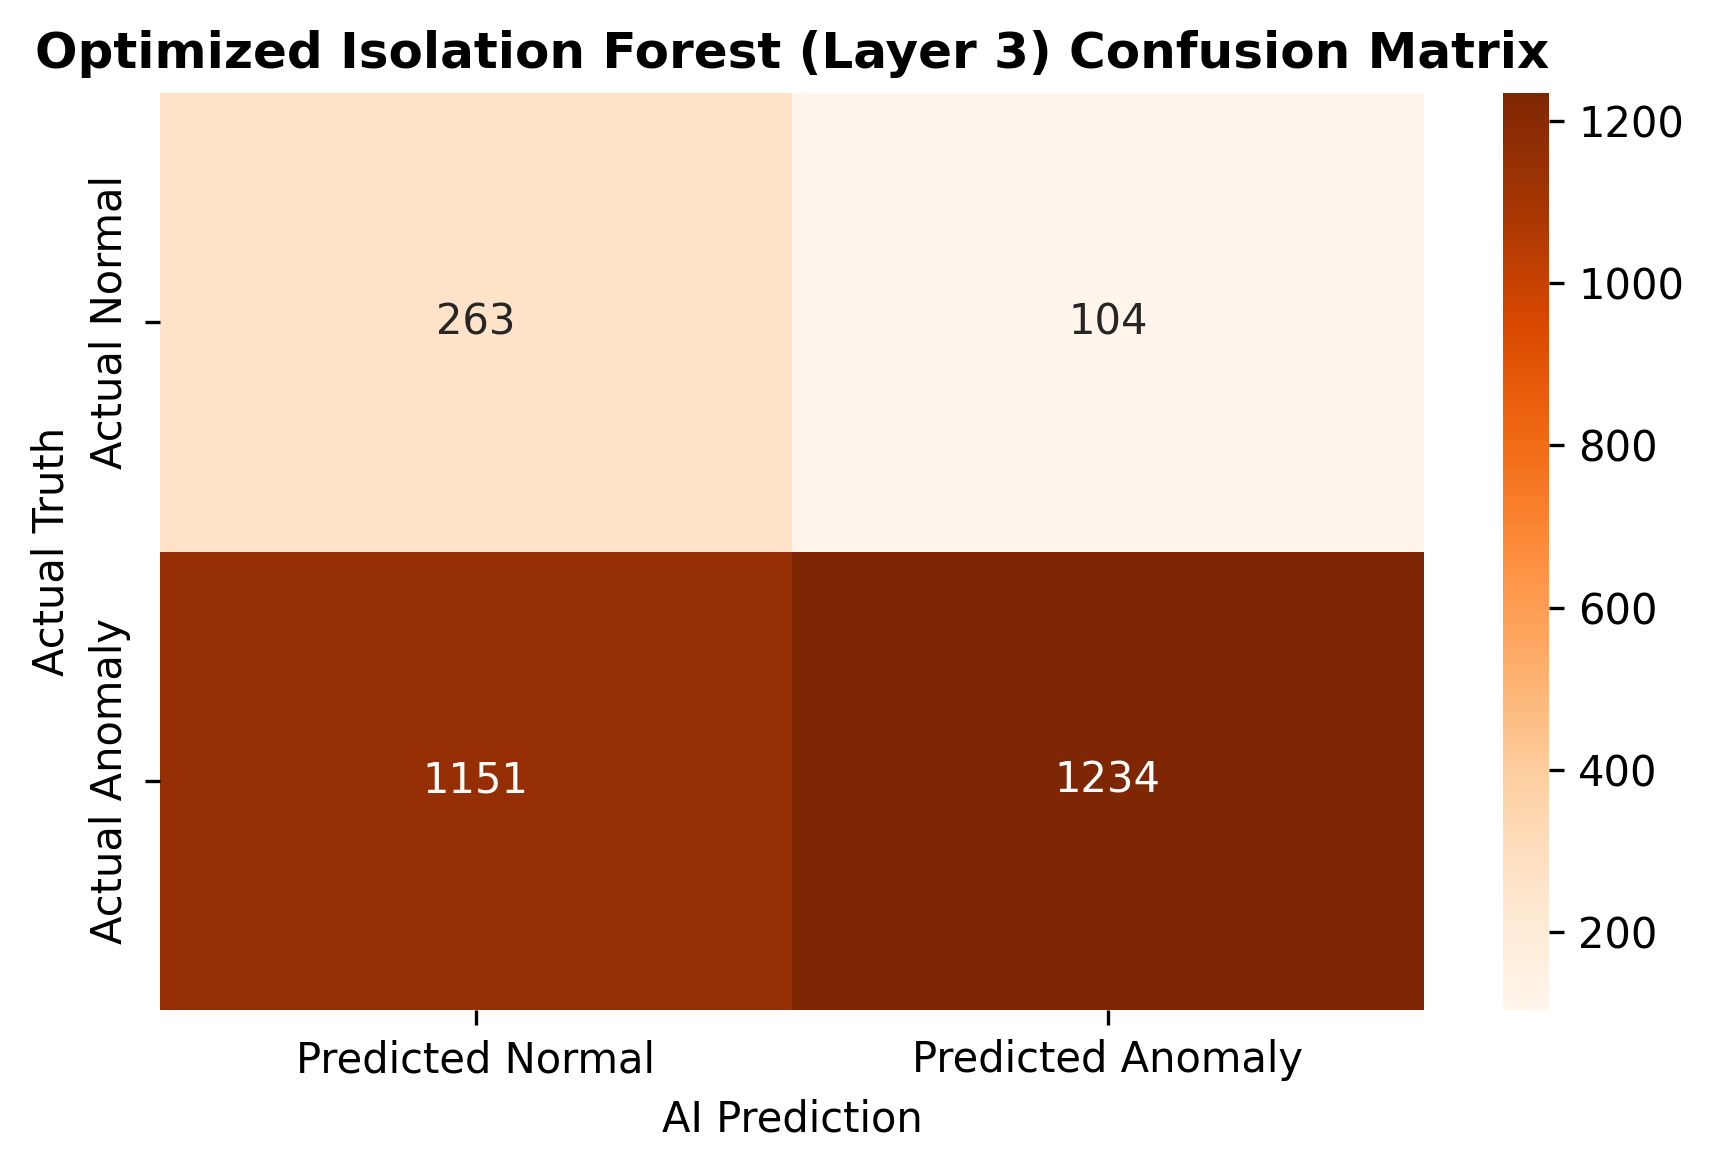

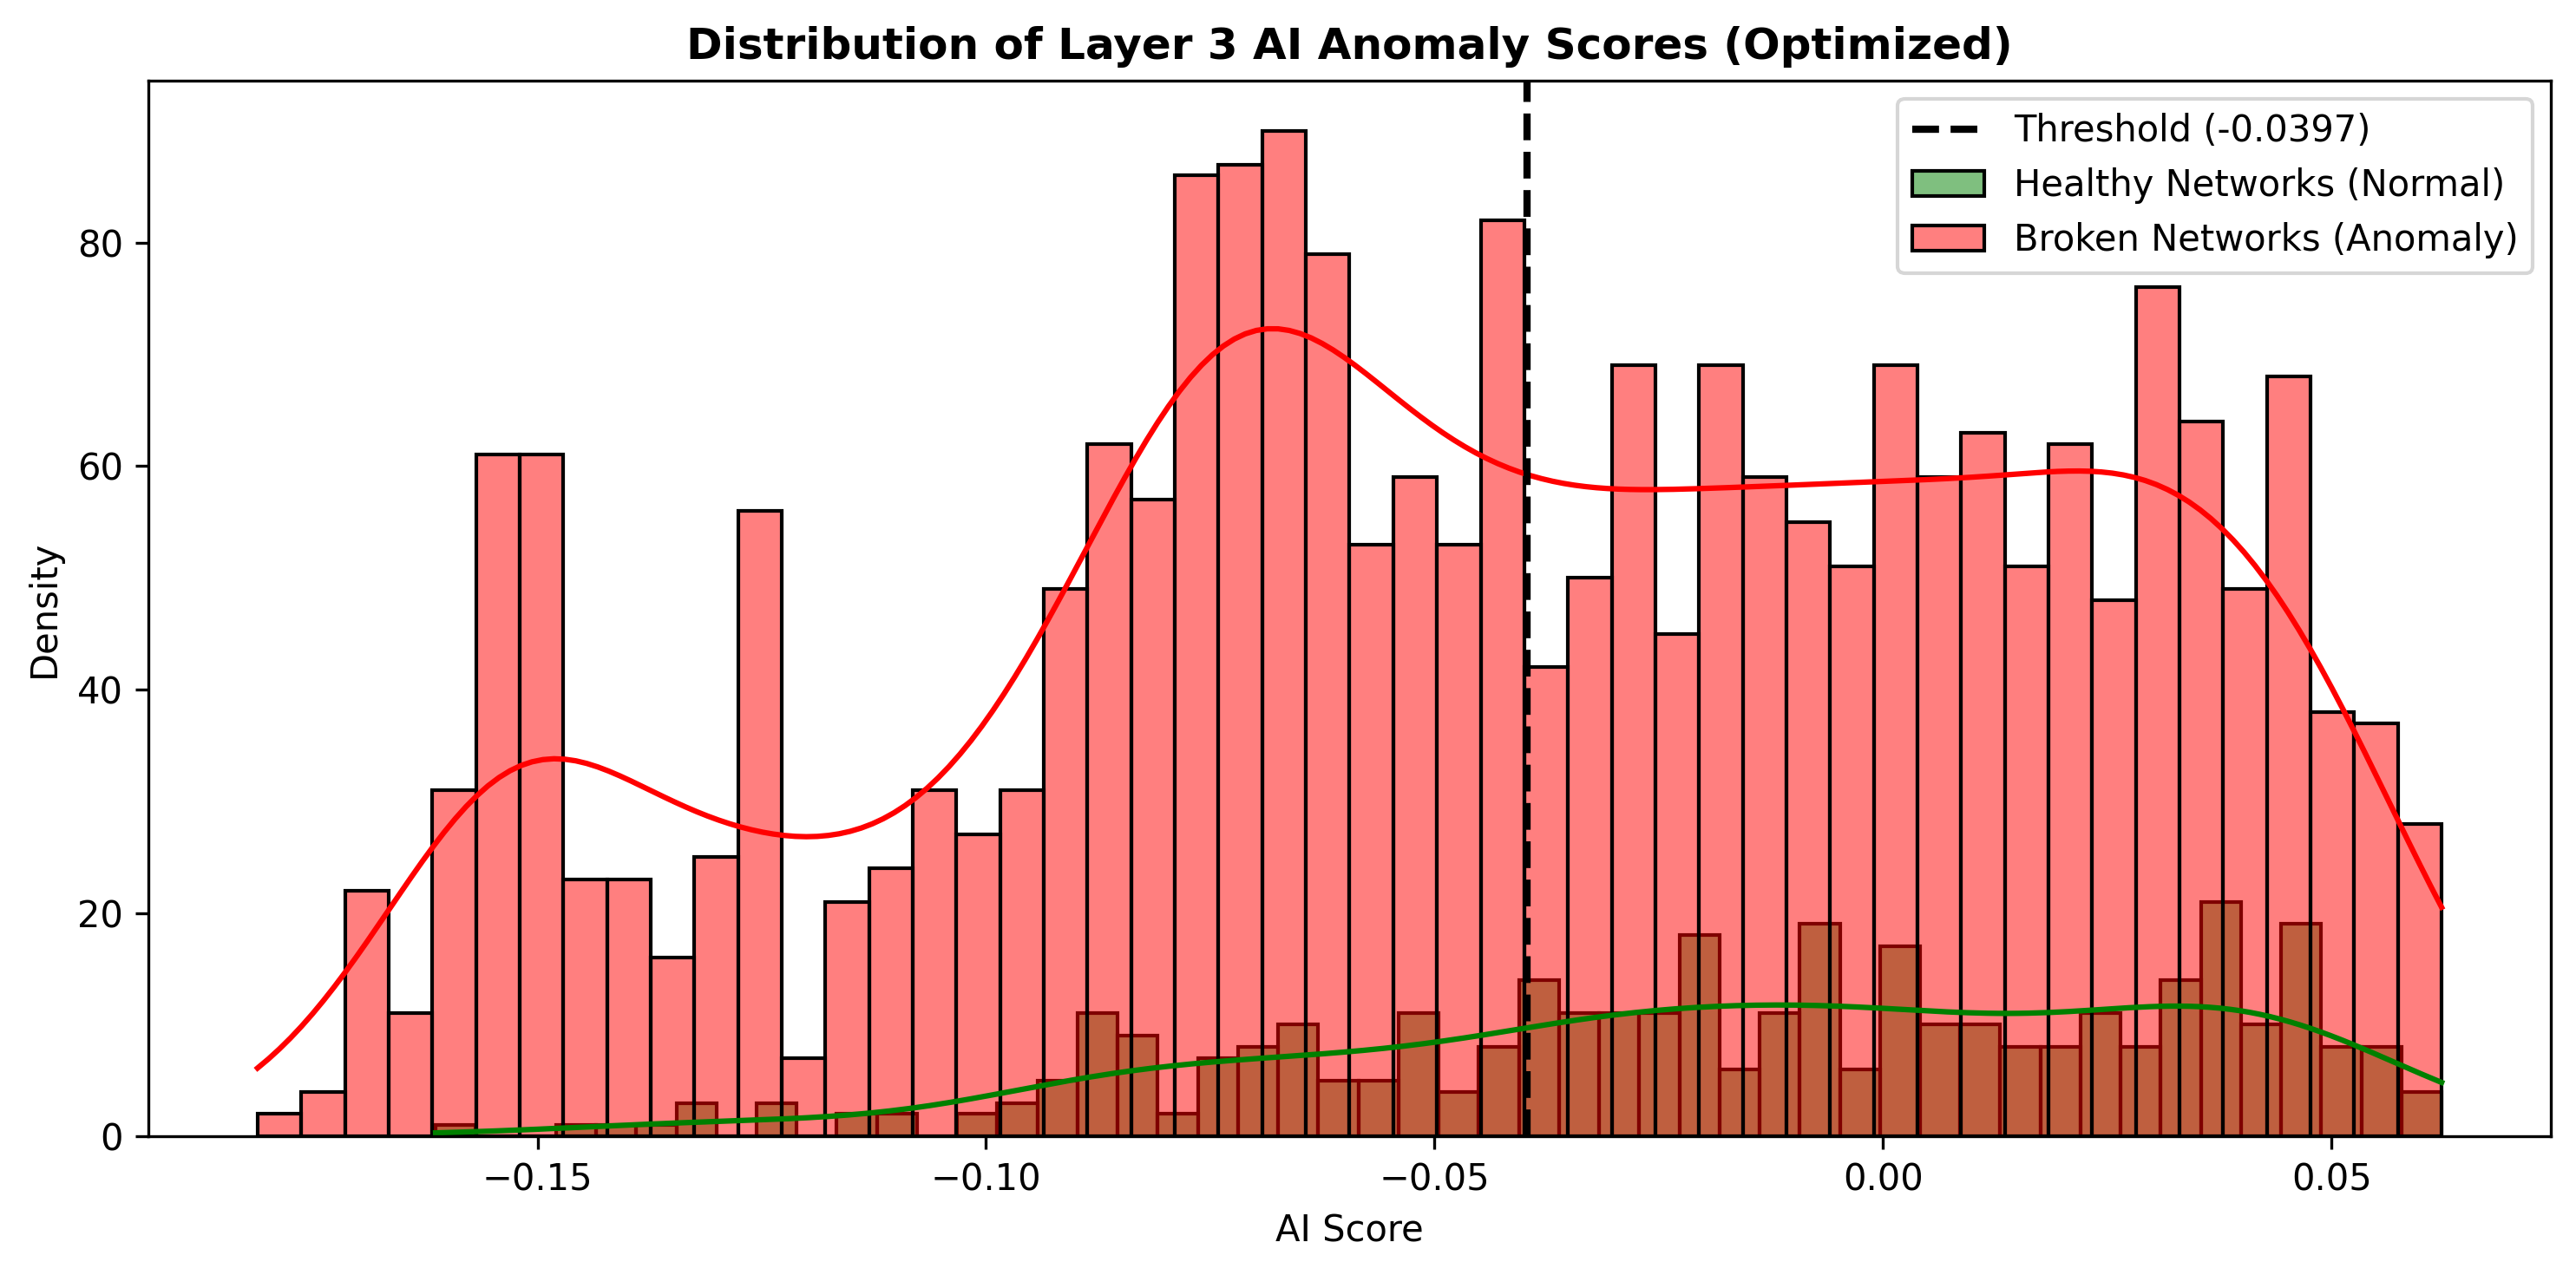

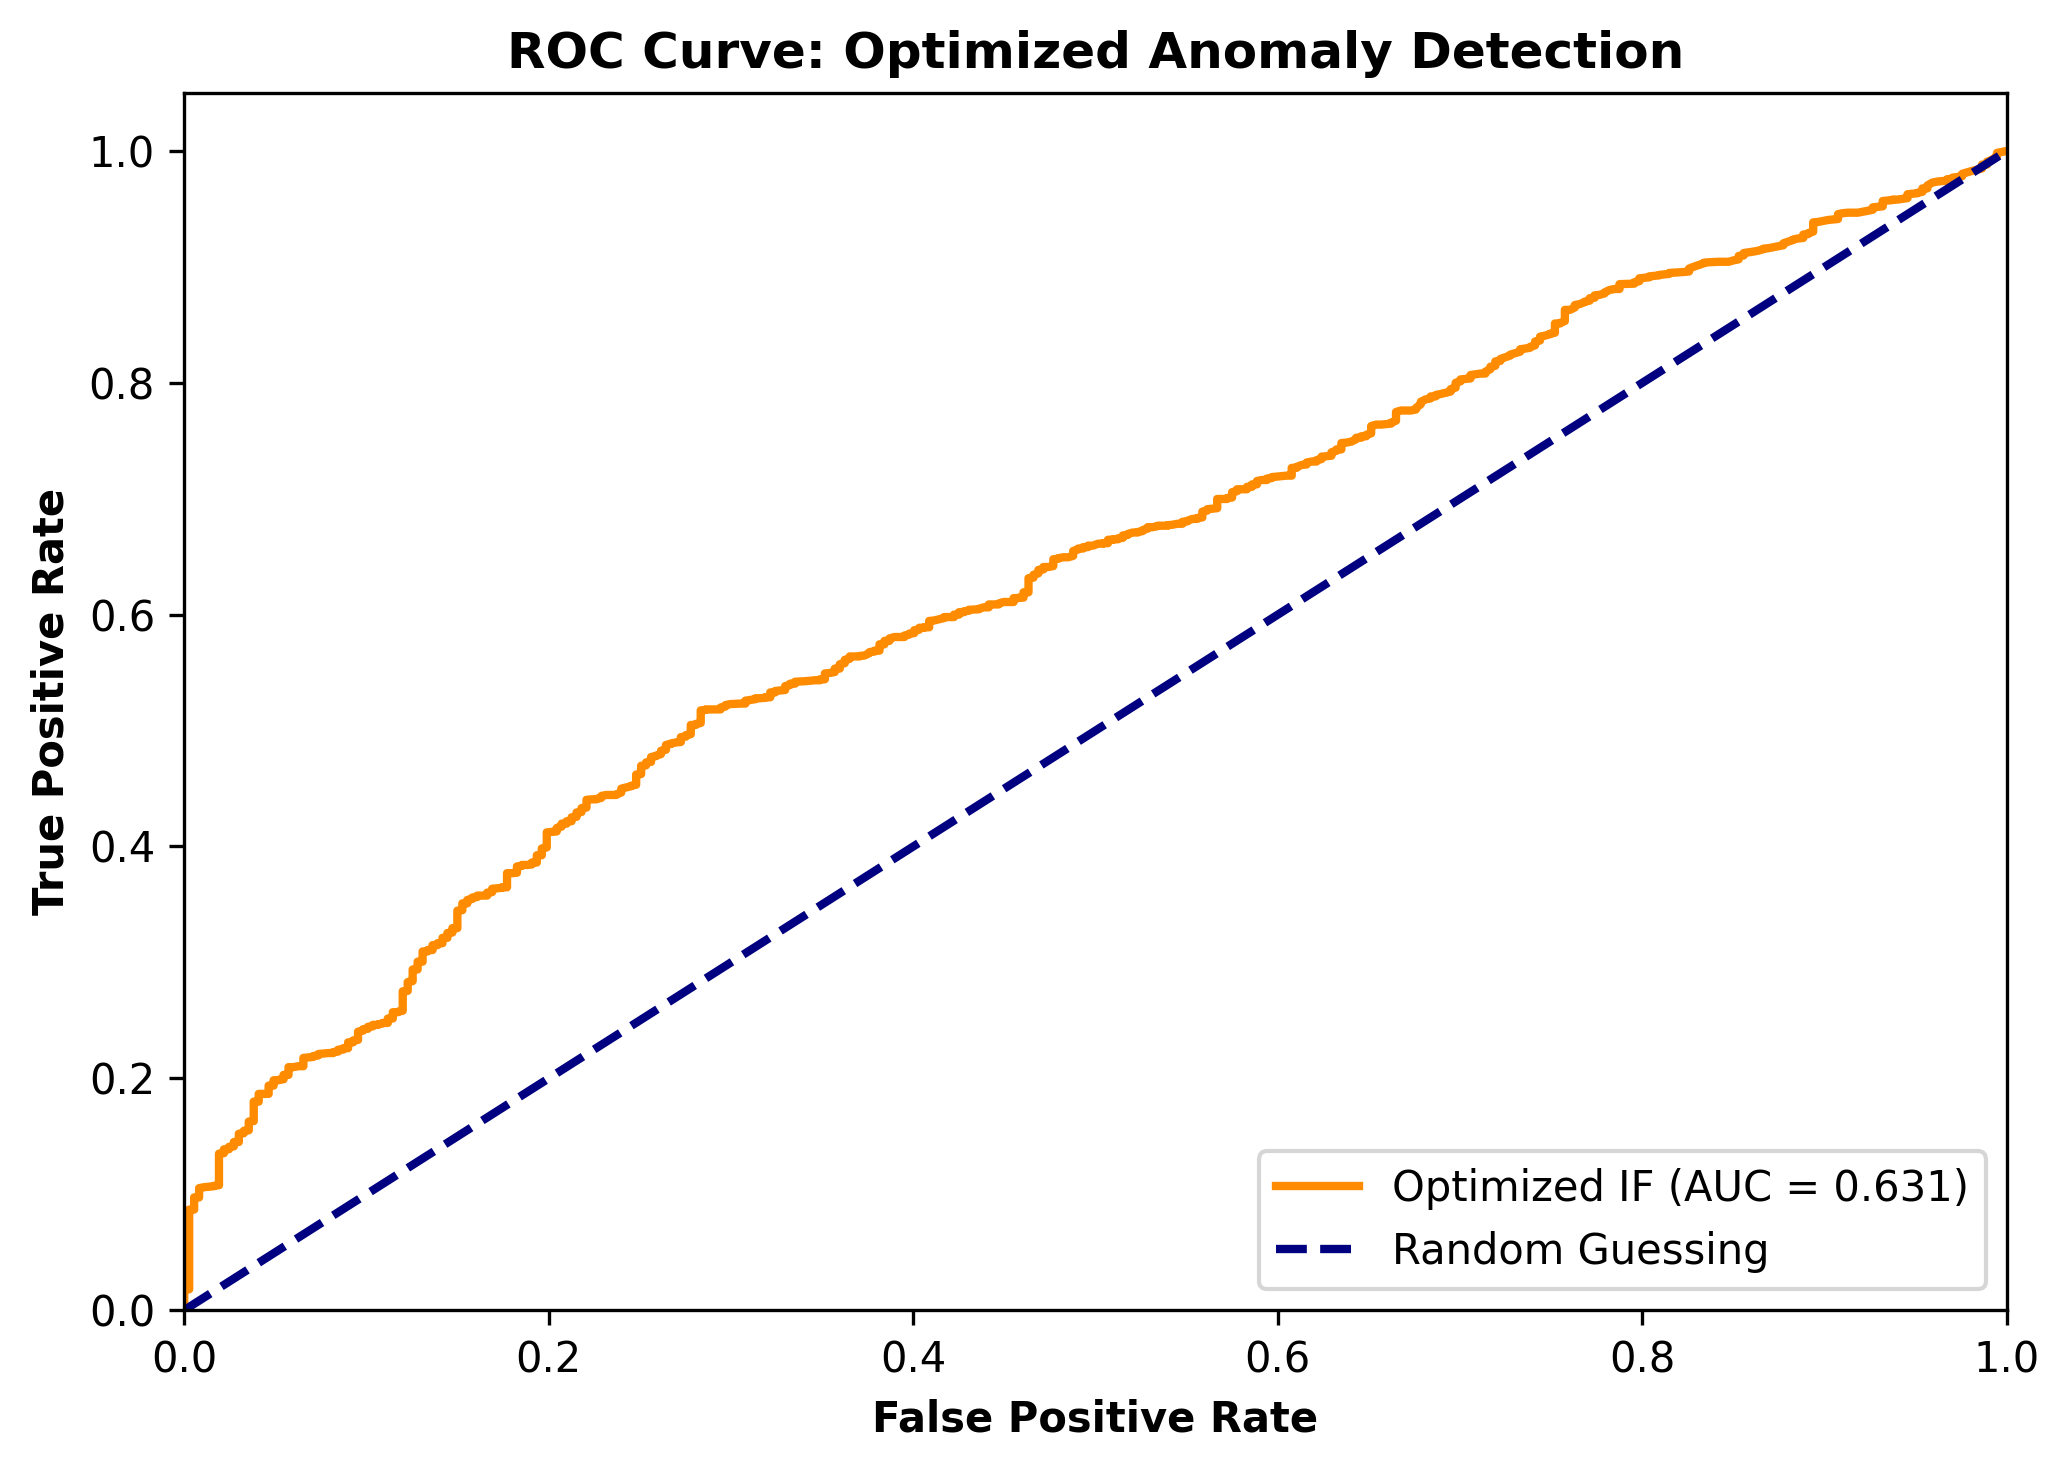


--- ALL STEPS COMPLETED SUCCESSFULLY! ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, balanced_accuracy_score
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network', 'Link_Profile',
                'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B',
                'Risk_Level', 'Error_Type']

features_to_check = df_features.drop(columns=cols_to_drop)
df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)
print(f"Original Records: {len(df_features)} | Cleaned Records: {len(df_clean)}")

print("\n--- STEP 2: FEATURE SPACE PARTITIONING ---")
continuous_features = [
    'Prefix_A',
    'Prefix_B',
    'subnet_capacity_a',
    'subnet_capacity_b',
    'device_a_degree',
    'device_b_degree',
    'subnet_reuse_count'
]

print(f"Features mapped to Layer 3 (Continuous Only): {continuous_features}")

df_normal = df_clean[df_clean['Label'] == 0]
df_anomaly = df_clean[df_clean['Label'] == 1]

normal_train, normal_test = train_test_split(df_normal, test_size=0.20, random_state=42)

df_test_mixed = pd.concat([normal_test, df_anomaly])

X_train_continuous = normal_train[continuous_features]
X_test_continuous = df_test_mixed[continuous_features]
y_test_actual = df_test_mixed['Label']

print(f"Training strictly on {len(X_train_continuous)} NORMAL records...")
print(f"Testing on mixed set of {len(X_test_continuous)} records ({len(normal_test)} Normal, {len(df_anomaly)} Anomalies)")

print("\n--- STEP 3: MODEL TRAINING WITH MAX_SAMPLES FIX ---")
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination='auto',
    random_state=42
)

iso_forest.fit(X_train_continuous)
test_scores = iso_forest.decision_function(X_test_continuous)

print("\n--- STEP 4: OPTIMIZING THRESHOLD ---")
thresholds = np.linspace(-0.2, 0.2, 500)
best_threshold = 0.0
best_balanced_acc = 0.0

for t in thresholds:
    y_pred_temp = (test_scores < t).astype(int)
    current_balanced_acc = balanced_accuracy_score(y_test_actual, y_pred_temp)

    if current_balanced_acc > best_balanced_acc:
        best_balanced_acc = current_balanced_acc
        best_threshold = t

y_pred_best = (test_scores < best_threshold).astype(int)
standard_accuracy = accuracy_score(y_test_actual, y_pred_best)

print(f"Optimal Threshold Found: {best_threshold:.4f}")
print(f"Calibrated Standard Accuracy: {standard_accuracy * 100:.2f}%")
print(f"Calibrated Balanced Accuracy: {best_balanced_acc * 100:.2f}%")

print("\n--- STEP 5: EVALUATION & CONFUSION MATRIX ---")
cm = confusion_matrix(y_test_actual, y_pred_best)

print(f"True Positives (Caught Errors)     : {cm[1][1]}")
print(f"True Negatives (Correctly Passed)  : {cm[0][0]}")
print(f"False Positives (FALSE ALARMS)     : {cm[0][1]}")
print(f"False Negatives (MISSED ERRORS)    : {cm[1][0]}\n")
print(classification_report(y_test_actual, y_pred_best, target_names=["Normal (0)", "Anomaly (1)"]))

print("\n--- STEP 6: GENERATING ACADEMIC PLOTS ---")

plt.figure(figsize=(6, 4), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Optimized Isolation Forest (Layer 3) Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.tight_layout()
plt.savefig('Thesis_Optimized_IF_Confusion_Matrix.png')
plt.show()

plt.figure(figsize=(10, 5), dpi=300)
sns.histplot(test_scores[y_test_actual == 0], color='green', label='Healthy Networks (Normal)', kde=True, bins=50, alpha=0.5)
sns.histplot(test_scores[y_test_actual == 1], color='red', label='Broken Networks (Anomaly)', kde=True, bins=50, alpha=0.5)
plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_threshold:.4f})')
plt.title('Distribution of Layer 3 AI Anomaly Scores (Optimized)', fontweight='bold')
plt.xlabel('AI Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('Thesis_Optimized_Score_Overlap.png')
plt.show()

inverted_scores = -test_scores
fpr, tpr, _ = roc_curve(y_test_actual, inverted_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Optimized IF (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve: Optimized Anomaly Detection', fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('Thesis_Optimized_ROC_Curve.png')
plt.show()

print("\n--- ALL STEPS COMPLETED SUCCESSFULLY! ---")

--- STEP 1: LOAD AND CLEAN DATASET ---
Original Records: 5000 | Cleaned Records: 4219

--- STEP 2: FEATURE SPACE PARTITIONING ---
Features mapped to Layer 3 (Continuous Only): ['Prefix_A', 'Prefix_B', 'subnet_capacity_a', 'subnet_capacity_b', 'device_a_degree', 'device_b_degree', 'subnet_reuse_count']
Training strictly on 1467 NORMAL records...
Testing on mixed set of 2752 records (367 Normal, 2385 Anomalies)

--- STEP 3: MODEL TRAINING (KERNEL TRICK VIA OCSVM) ---

--- STEP 4: OPTIMIZING THRESHOLD ---
Optimal Threshold Found: -0.0003
Calibrated Standard Accuracy: 50.40%
Calibrated Balanced Accuracy: 71.04%

--- STEP 5: EVALUATION & CONFUSION MATRIX ---
True Positives (Caught Errors)     : 1023
True Negatives (Correctly Passed)  : 364
False Positives (FALSE ALARMS)     : 3
False Negatives (MISSED ERRORS)    : 1362

              precision    recall  f1-score   support

  Normal (0)       0.21      0.99      0.35       367
 Anomaly (1)       1.00      0.43      0.60      2385

    accur

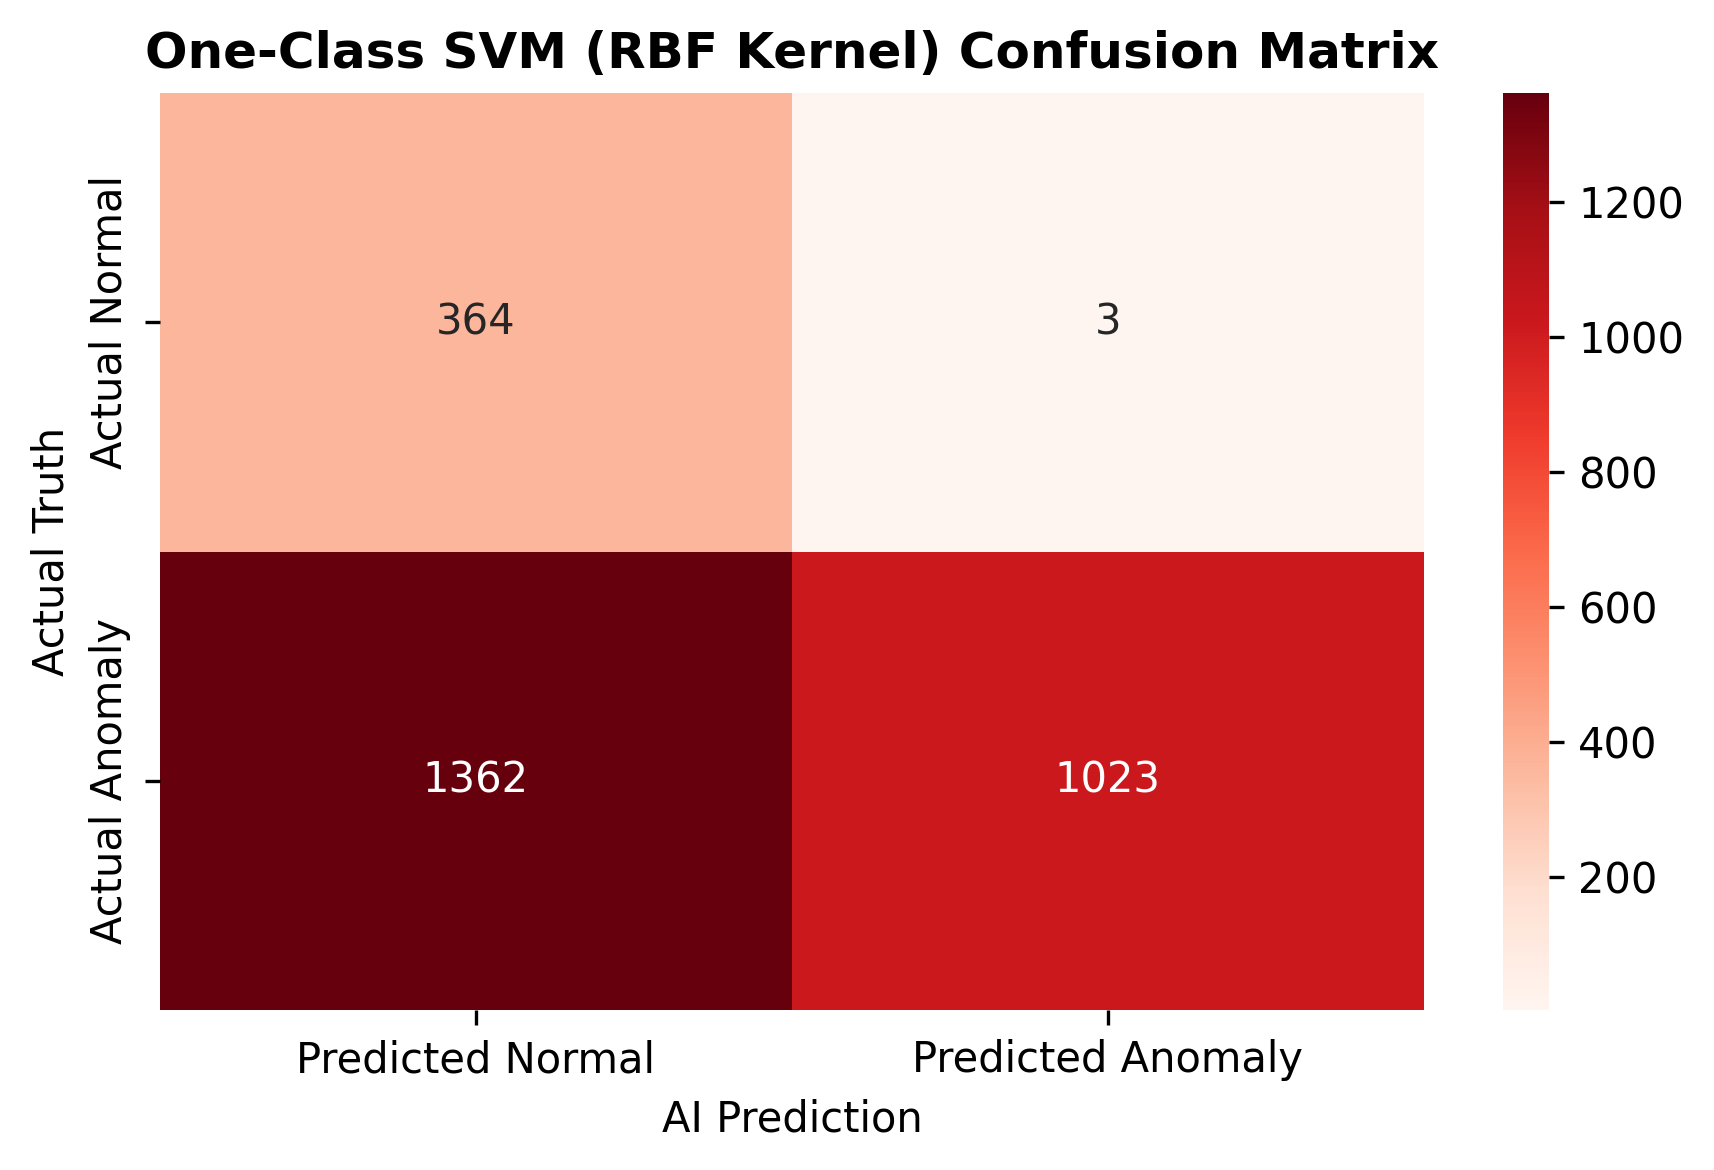

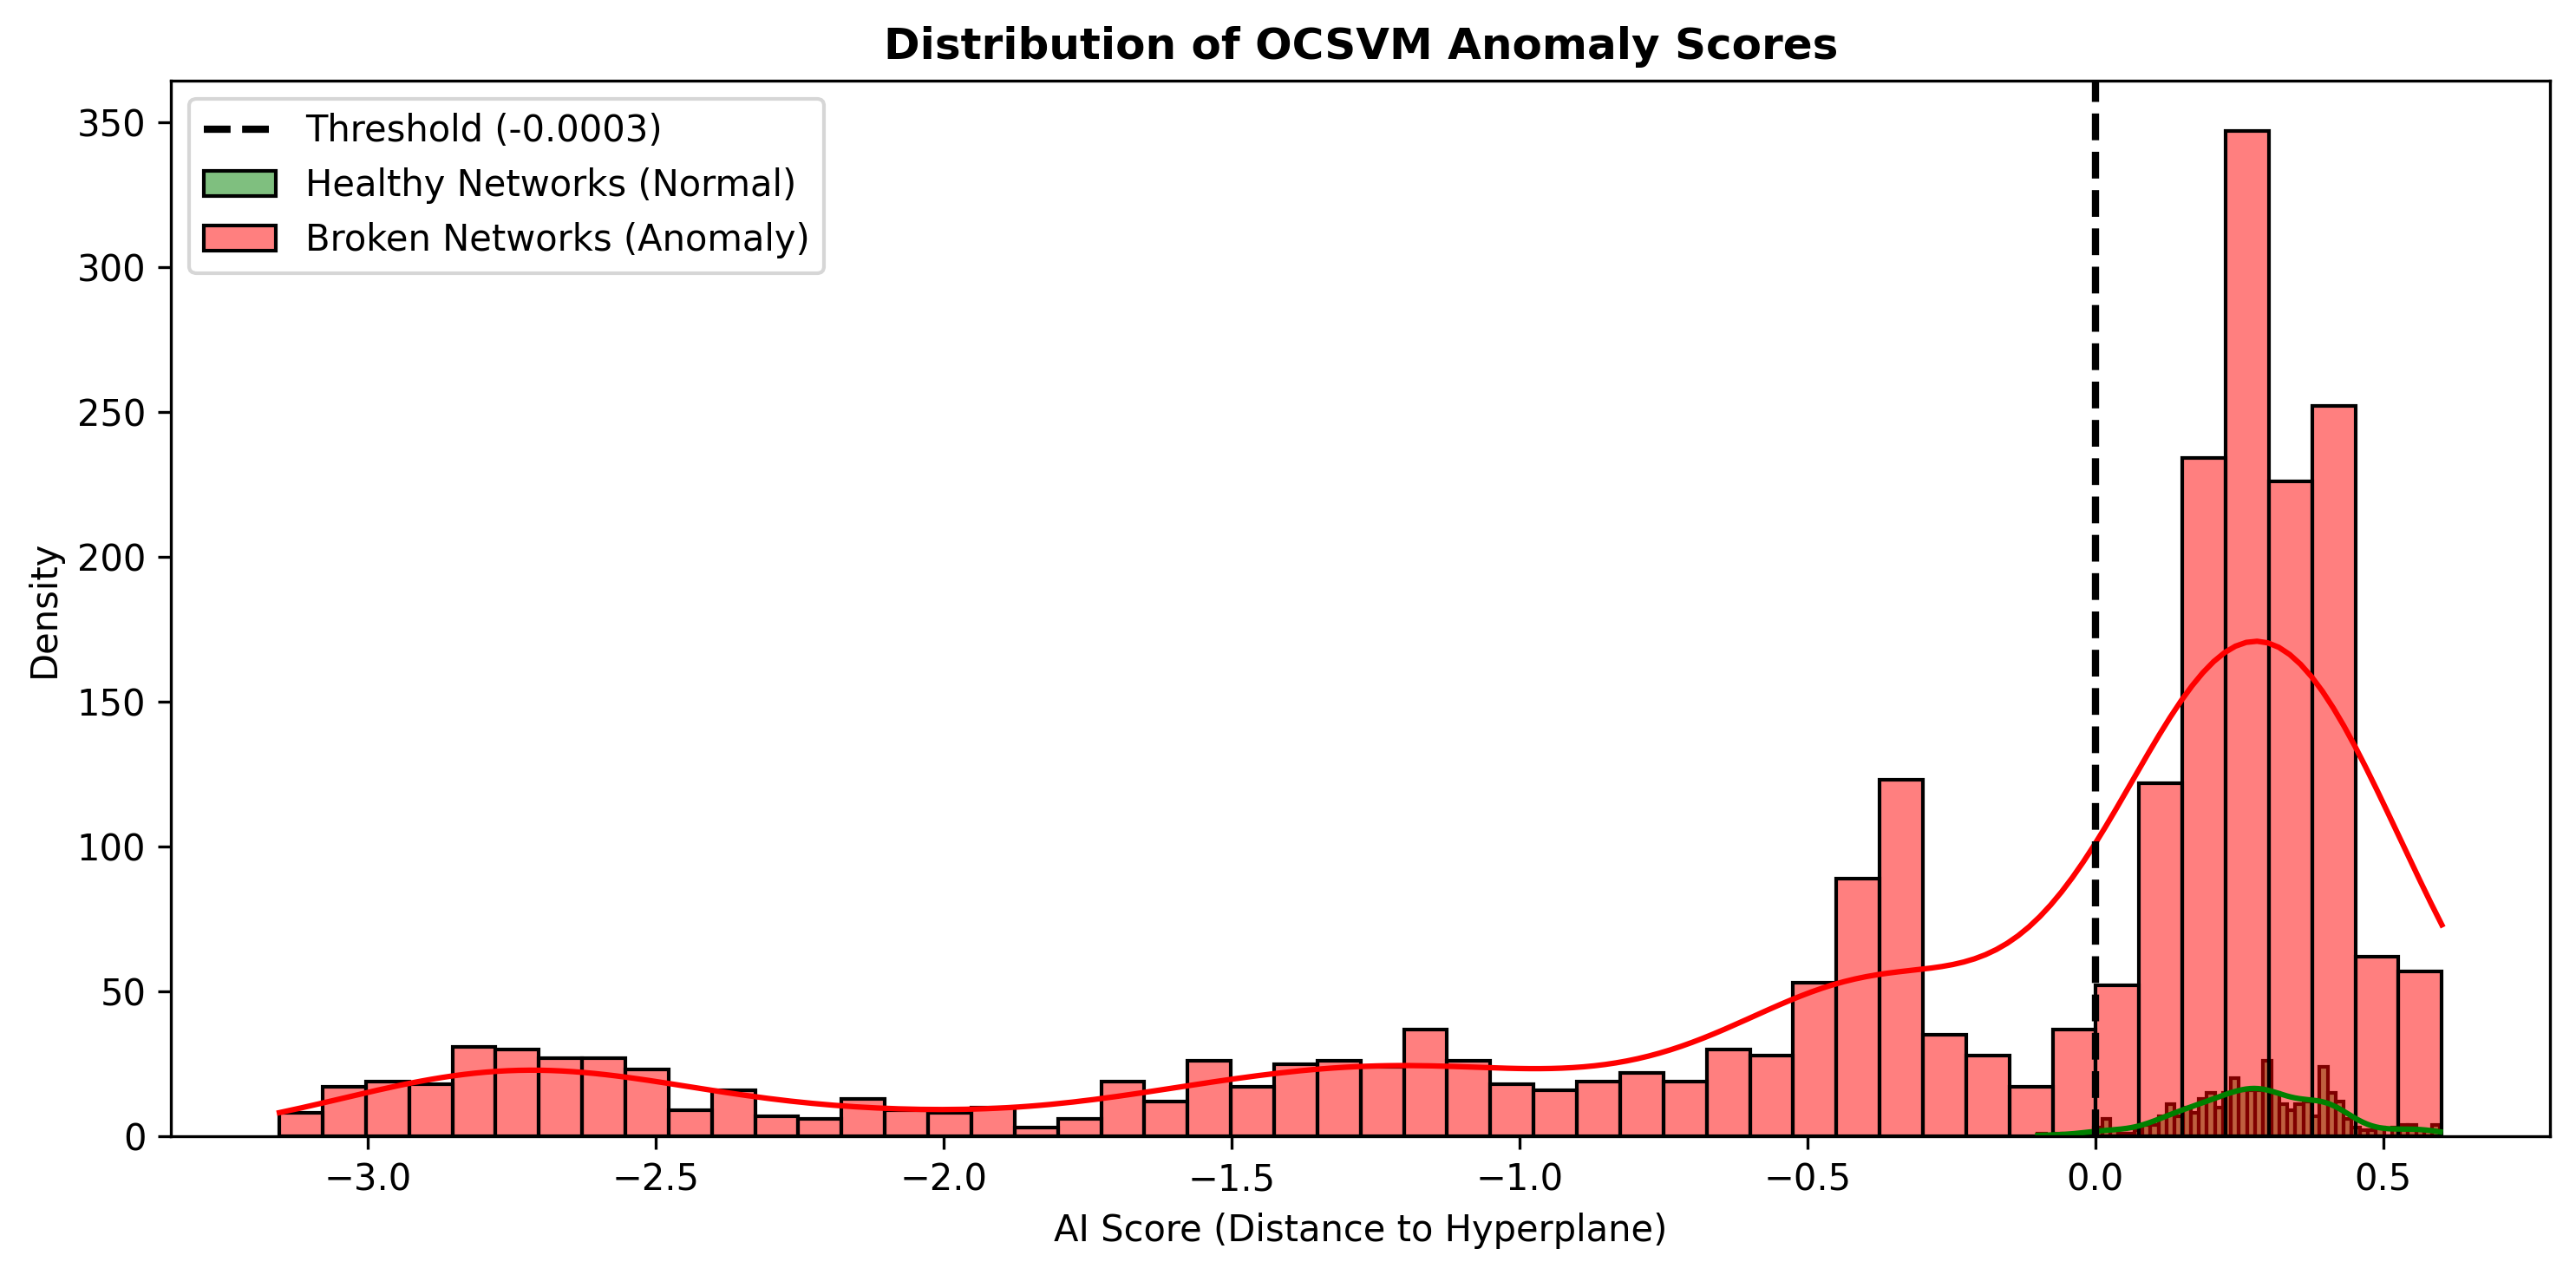

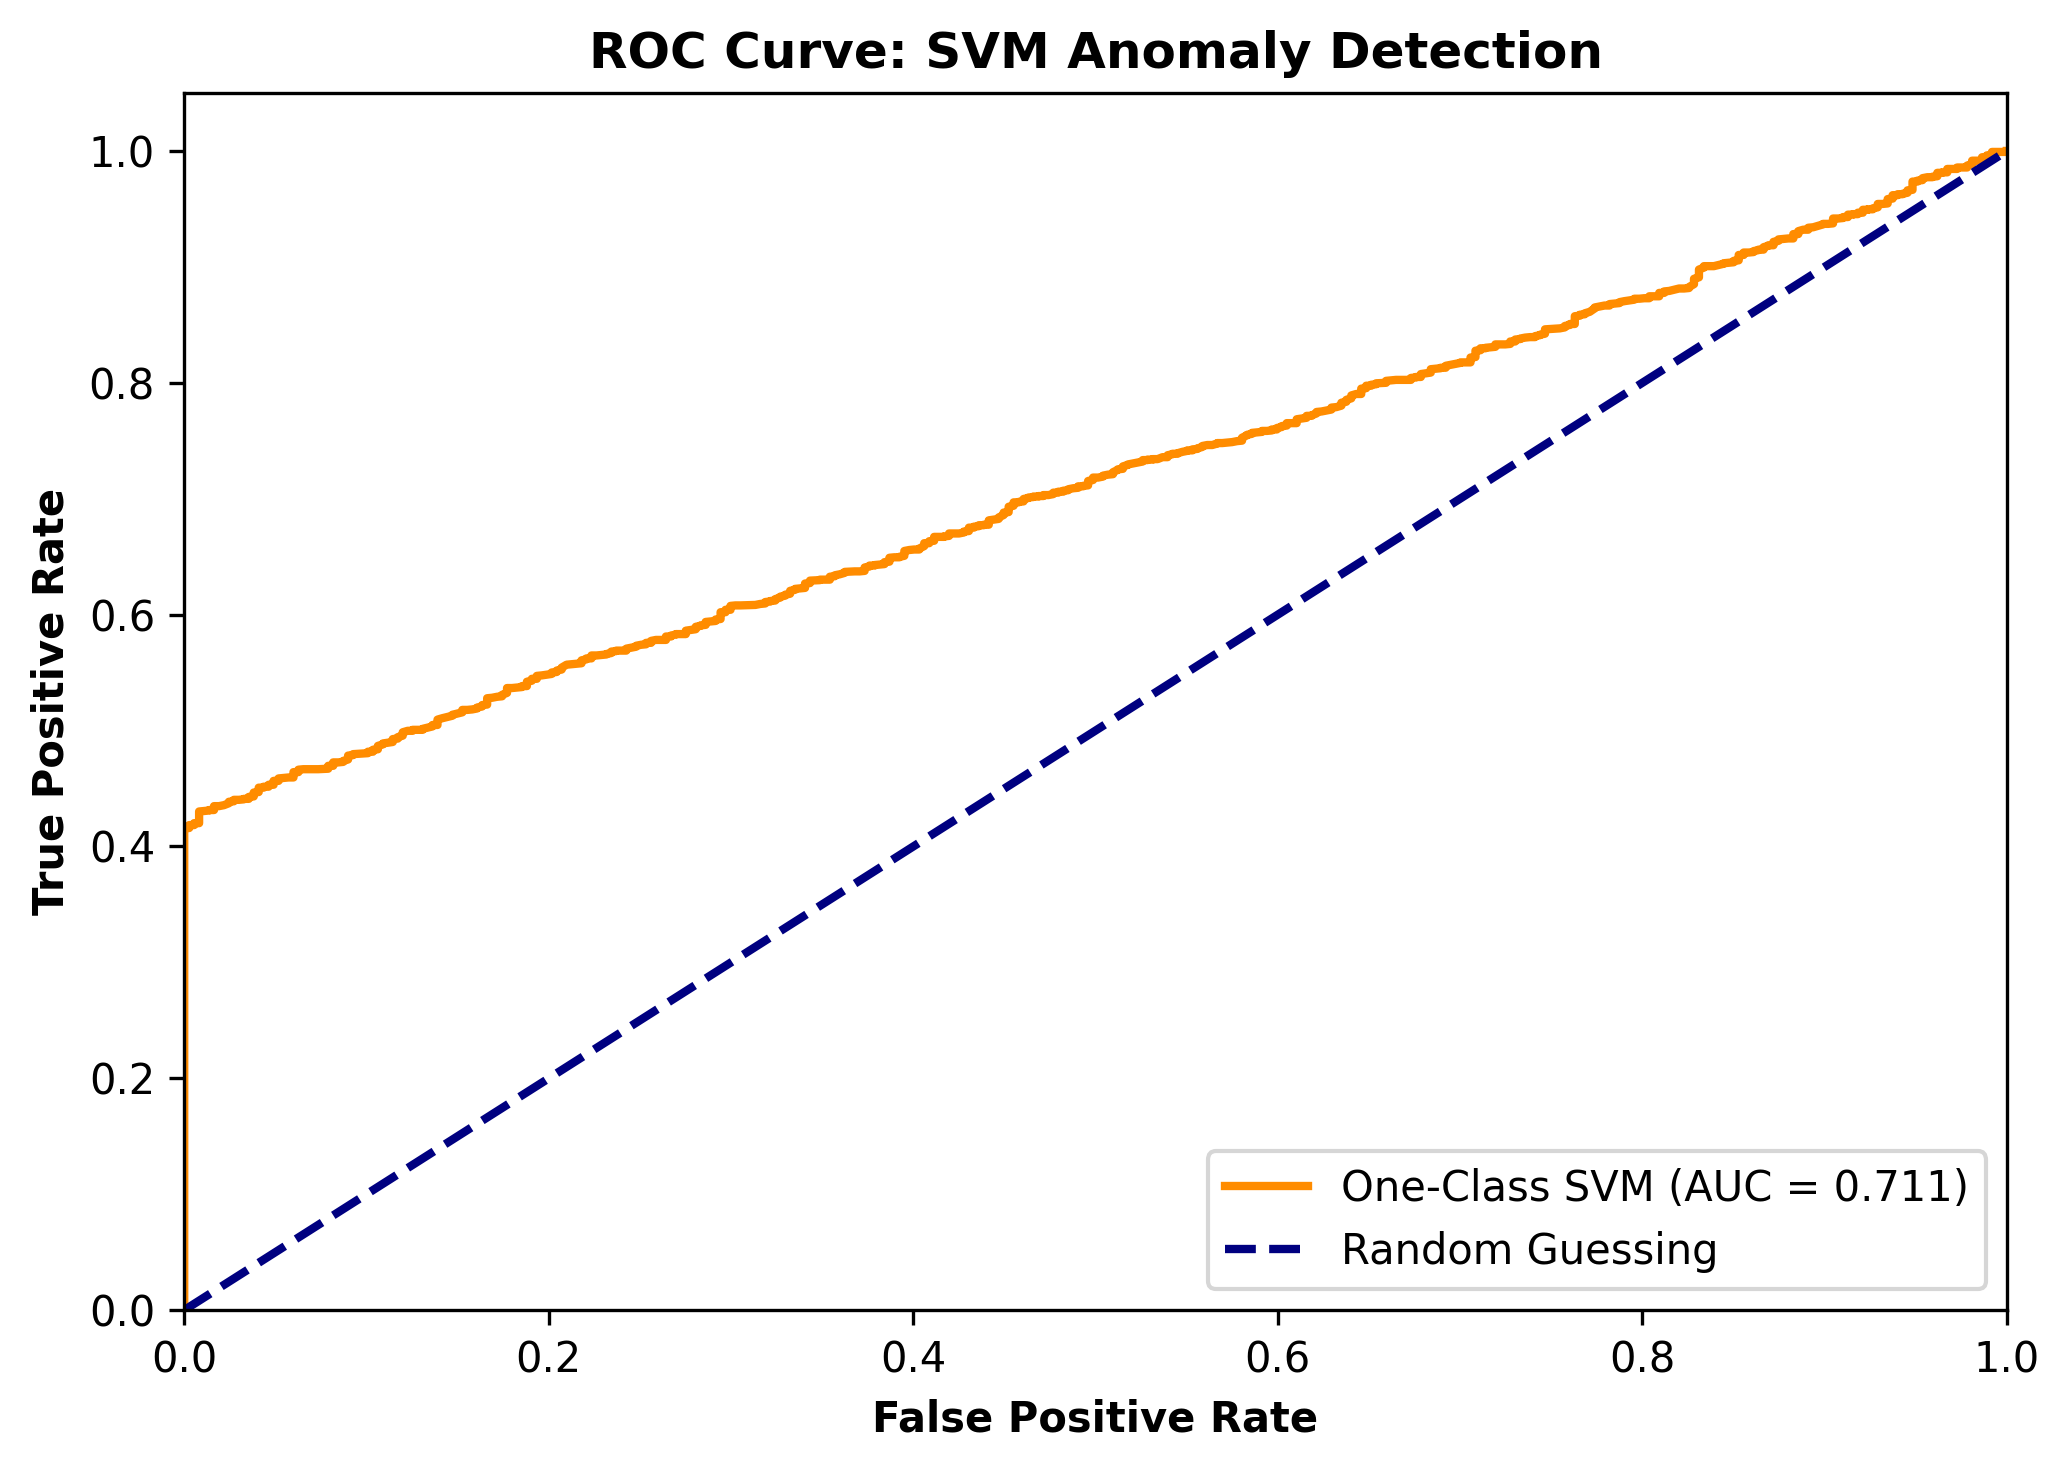


--- ALL STEPS COMPLETED SUCCESSFULLY! ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, balanced_accuracy_score
import warnings

warnings.filterwarnings('ignore')

print("--- STEP 1: LOAD AND CLEAN DATASET ---")
df_features = pd.read_csv('dataset_v5_features.csv')

cols_to_drop = ['Sample_ID', 'Link_ID', 'Network', 'Link_Profile',
                'Device_A_Role', 'Device_B_Role', 'IP_Range_A', 'IP_Range_B',
                'Risk_Level', 'Error_Type']

features_to_check = df_features.drop(columns=cols_to_drop)

df_clean = df_features.loc[~features_to_check.duplicated()].reset_index(drop=True)
print(f"Original Records: {len(df_features)} | Cleaned Records: {len(df_clean)}")

print("\n--- STEP 2: FEATURE SPACE PARTITIONING ---")
continuous_features = [
    'Prefix_A',
    'Prefix_B',
    'subnet_capacity_a',
    'subnet_capacity_b',
    'device_a_degree',
    'device_b_degree',
    'subnet_reuse_count'
]

print(f"Features mapped to Layer 3 (Continuous Only): {continuous_features}")

df_normal = df_clean[df_clean['Label'] == 0]
df_anomaly = df_clean[df_clean['Label'] == 1]

normal_train, normal_test = train_test_split(df_normal, test_size=0.20, random_state=42)

df_test_mixed = pd.concat([normal_test, df_anomaly])

X_train_continuous = normal_train[continuous_features]
X_test_continuous = df_test_mixed[continuous_features]
y_test_actual = df_test_mixed['Label']

print(f"Training strictly on {len(X_train_continuous)} NORMAL records...")
print(f"Testing on mixed set of {len(X_test_continuous)} records ({len(normal_test)} Normal, {len(df_anomaly)} Anomalies)")

print("\n--- STEP 3: MODEL TRAINING (KERNEL TRICK VIA OCSVM) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_continuous)
X_test_scaled = scaler.transform(X_test_continuous)

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.01
)

ocsvm.fit(X_train_scaled)

test_scores = ocsvm.decision_function(X_test_scaled)

print("\n--- STEP 4: OPTIMIZING THRESHOLD ---")
thresholds = np.linspace(test_scores.min(), test_scores.max(), 500)
best_threshold = 0.0
best_balanced_acc = 0.0

for t in thresholds:
    y_pred_temp = (test_scores < t).astype(int)
    current_balanced_acc = balanced_accuracy_score(y_test_actual, y_pred_temp)

    if current_balanced_acc > best_balanced_acc:
        best_balanced_acc = current_balanced_acc
        best_threshold = t

y_pred_best = (test_scores < best_threshold).astype(int)
standard_accuracy = accuracy_score(y_test_actual, y_pred_best)

print(f"Optimal Threshold Found: {best_threshold:.4f}")
print(f"Calibrated Standard Accuracy: {standard_accuracy * 100:.2f}%")
print(f"Calibrated Balanced Accuracy: {best_balanced_acc * 100:.2f}%")

print("\n--- STEP 5: EVALUATION & CONFUSION MATRIX ---")
cm = confusion_matrix(y_test_actual, y_pred_best)

print(f"True Positives (Caught Errors)     : {cm[1][1]}")
print(f"True Negatives (Correctly Passed)  : {cm[0][0]}")
print(f"False Positives (FALSE ALARMS)     : {cm[0][1]}")
print(f"False Negatives (MISSED ERRORS)    : {cm[1][0]}\n")
print(classification_report(y_test_actual, y_pred_best, target_names=["Normal (0)", "Anomaly (1)"]))

print("\n--- STEP 6: GENERATING ACADEMIC PLOTS ---")

plt.figure(figsize=(6, 4), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('One-Class SVM (RBF Kernel) Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.tight_layout()
plt.savefig('Thesis_OCSVM_Confusion_Matrix.png')
plt.show()


plt.figure(figsize=(10, 5), dpi=300)
sns.histplot(test_scores[y_test_actual == 0], color='green', label='Healthy Networks (Normal)', kde=True, bins=50, alpha=0.5)
sns.histplot(test_scores[y_test_actual == 1], color='red', label='Broken Networks (Anomaly)', kde=True, bins=50, alpha=0.5)
plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_threshold:.4f})')
plt.title('Distribution of OCSVM Anomaly Scores', fontweight='bold')
plt.xlabel('AI Score (Distance to Hyperplane)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('Thesis_OCSVM_Score_Overlap.png')
plt.show()

inverted_scores = -test_scores
fpr, tpr, _ = roc_curve(y_test_actual, inverted_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'One-Class SVM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve: SVM Anomaly Detection', fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('Thesis_OCSVM_ROC_Curve.png')
plt.show()

print("\n--- ALL STEPS COMPLETED SUCCESSFULLY! ---")